## Библиотеки

In [1]:
!pip install emoji
!pip install gensim
# pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.3 MB/s eta 0:00:00


In [32]:
import os
import warnings
import time
import random
import re
import string
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, SnowballStemmer
import emoji

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from scipy.special import softmax

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
warnings.filterwarnings('ignore')

In [33]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Загрузка датасета
ds_full = load_dataset("Tobi-Bueck/customer-support-tickets")
base_dataset = ds_full["train"]

# Загрузка индексов
def load_local_indices(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f if line.strip()]

train_indices = load_local_indices("data/train_idx.txt")
val_indices = load_local_indices("data/val_idx.txt")
test_indices = load_local_indices("data/test_idx.txt")

# Создание сплитов
ds_train = base_dataset.select(train_indices)
ds_val = base_dataset.select(val_indices)
ds_test = base_dataset.select(test_indices)


df = base_dataset.to_pandas()

# Заполняем пропуски
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

# Создаём текст
df['text'] = df['subject'] + ' ' + df['body']

# Добавляем сплит
def get_split(idx):
    if idx in train_indices:
        return 'train'
    elif idx in val_indices:
        return 'val'
    elif idx in test_indices:
        return 'test'
    return 'unknown'

df['split'] = df.index.map(get_split)

In [34]:
print(f"Train: {len(ds_train)} ")
print(f"Val:   {len(ds_val)} ")
print(f"Test:  {len(ds_test)} ")
print(f"Total: {len(ds_train) + len(ds_val) + len(ds_test)}")

train_set = set(train_indices)
val_set = set(val_indices)
test_set = set(test_indices)

print(f"Train ∩ Val:  {len(train_set & val_set)}")
print(f"Train ∩ Test: {len(train_set & test_set)}")
print(f"Val ∩ Test:   {len(val_set & test_set)}")
print(f"Seed: {SEED}")

def analyze_duplicates(max_show=15):
    full_duplicates = df.duplicated(subset=['text'], keep=False)
    dup_df = df[full_duplicates].copy()

    print("\n=== ДУБЛИКАТЫ МЕЖДУ СПЛИТАМИ ===\n")

    count = 0
    for text, group in dup_df.groupby('text'):
        splits = group['split'].unique()

        if len(splits) > 1:
            count += 1
            if count > max_show:
                break

            train_rows = group[group['split'] == 'train']
            val_rows = group[group['split'] == 'val']
            test_rows = group[group['split'] == 'test']

            print("=" * 80)
            print(f"#{count} | Сплиты: {list(splits)} | Лейблы: queue={group['queue'].iloc[0]}")
            print("=" * 80)

            if not train_rows.empty:
                for idx in train_rows.index:
                    print(f"TRAIN [{idx}] | Subject: {str(df.loc[idx, 'subject'])[:80]}")

            if not val_rows.empty:
                for idx in val_rows.index:
                    print(f"VAL   [{idx}] | Subject: {str(df.loc[idx, 'subject'])[:80]}")

            if not test_rows.empty:
                for idx in test_rows.index:
                    print(f"TEST  [{idx}] | Subject: {str(df.loc[idx, 'subject'])[:80]}")

            print("-" * 80)

    print(f"\nВсего дубликатов между сплитами: {count} (показано первые {max_show})")

def analyze_language():
    df['text_len'] = df['text'].str.len()

    print("\n=== РАСПРЕДЕЛЕНИЕ ЯЗЫКОВ ===")
    print(df['language'].value_counts())

    print("\n=== СРЕДНЯЯ ДЛИНА ПО ЯЗЫКАМ ===")
    print(df.groupby('language')['text_len'].mean())

    print("\n=== ДЛИНА ТЕКСТА ПО ЯЗЫКАМ (статистика) ===")
    print(df.groupby('language')['text_len'].describe())

    print("\n=== ЯЗЫК ПО СПЛИТАМ ===")
    print(pd.crosstab(df['split'], df['language']))

analyze_duplicates()
analyze_language()

Train: 49412 
Val:   6176 
Test:  6177 
Total: 61765
Train ∩ Val:  0
Train ∩ Test: 0
Val ∩ Test:   0
Seed: 42

=== ДУБЛИКАТЫ МЕЖДУ СПЛИТАМИ ===


Всего дубликатов между сплитами: 0 (показано первые 15)

=== РАСПРЕДЕЛЕНИЕ ЯЗЫКОВ ===
language
de    33504
en    28261
Name: count, dtype: int64

=== СРЕДНЯЯ ДЛИНА ПО ЯЗЫКАМ ===
language
de    508.387416
en    410.305616
Name: text_len, dtype: float64

=== ДЛИНА ТЕКСТА ПО ЯЗЫКАМ (статистика) ===
            count        mean         std   min    25%    50%    75%     max
language                                                                    
de        33504.0  508.387416  235.989652  14.0  311.0  515.0  703.0  2284.0
en        28261.0  410.305616  203.523559   5.0  245.0  405.0  568.0  1825.0

=== ЯЗЫК ПО СПЛИТАМ ===
language     de     en
split                 
test       3330   2847
train     26799  22613
val        3375   2801


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   61765 non-null  object 
 1   body      61765 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
 16  text      61765 non-null  object 
 17  split     61765 non-null  object 
 18  text_len  61765 non-null  int64  
dtypes: float64(1), int64(1), object(17)
memory usage: 9.0+ MB


### Посмотрим распределение классов по целевым переменным

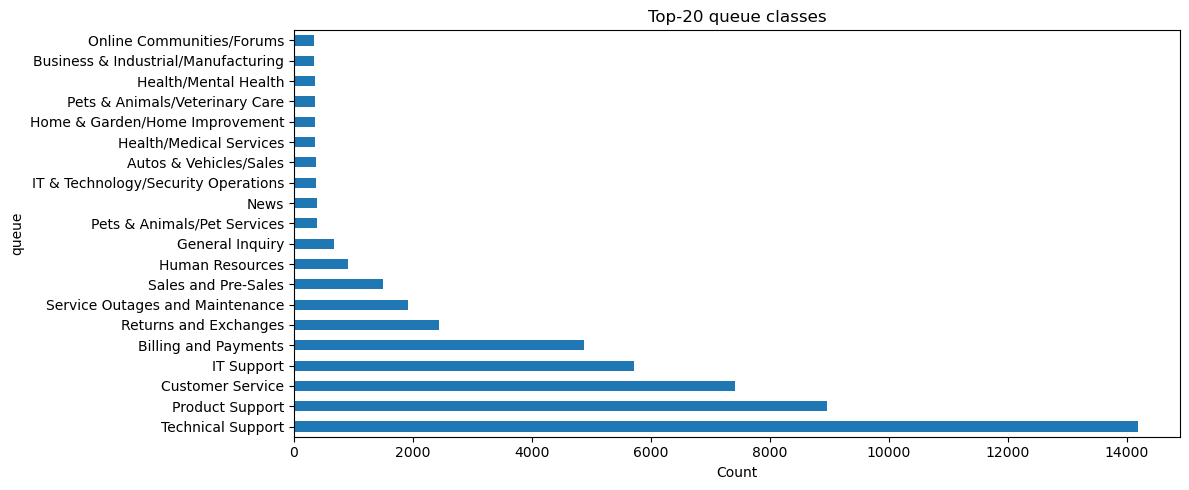

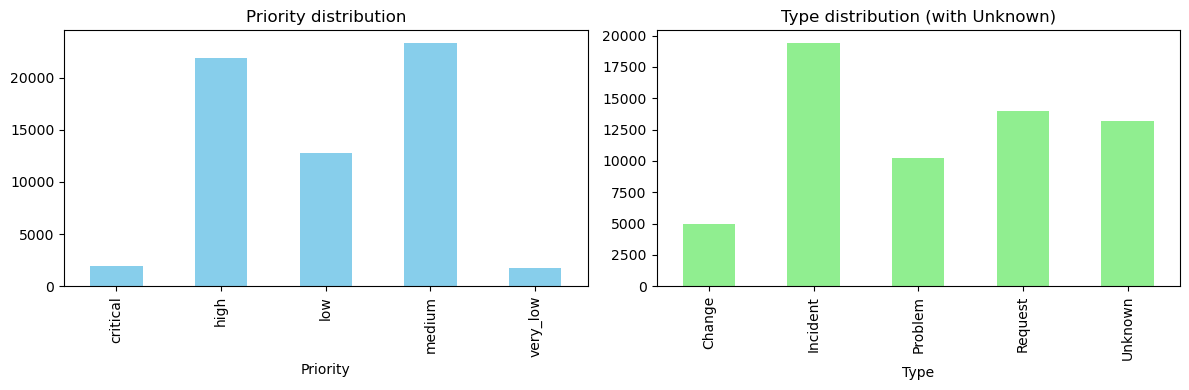

Уникальных queue: 52
Уникальных priority: 5
Уникальных type (с Unknown): 5


In [36]:
# Распределение queue (топ-20 для наглядности)
plt.figure(figsize=(12, 5))
df['queue'].value_counts().head(20).plot(kind='barh')
plt.title('Top-20 queue classes')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Распределение priority и type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['priority'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Priority distribution')
axes[0].set_xlabel('Priority')

df['type'].fillna('Unknown').value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Type distribution (with Unknown)')
axes[1].set_xlabel('Type')

plt.tight_layout()
plt.show()

# Статистика по количеству классов
print(f"Уникальных queue: {df['queue'].nunique()}")
print(f"Уникальных priority: {df['priority'].nunique()}")
print(f"Уникальных type (с Unknown): {df['type'].fillna('Unknown').nunique()}")

Long-tail distribution — модель будет склонна предсказывать частые классы \
Queue (52 класса) — Сильный дисбаланс \
Priority (5 классов) — Умеренный дисбаланс \


### Анализ длин текстов

=== Длины в символах ===
       subject_len_chars  body_len_chars  text_len_chars
count       61765.000000    61765.000000    61765.000000
mean           43.329993      419.179422      463.509415
std            22.927371      223.859775      227.044165
min             0.000000        0.000000        5.000000
25%            31.000000      234.000000      278.000000
50%            43.000000      415.000000      459.000000
75%            56.000000      587.000000      633.000000
max           675.000000     2259.000000     2284.000000

=== Длины в словах ===
       subject_len_words  body_len_words  text_len_words
count       61765.000000    61765.000000    61765.000000
mean            5.066462       57.362600       62.429062
std             2.734886       31.031029       31.230536
min             0.000000        0.000000        1.000000
25%             4.000000       31.000000       37.000000
50%             5.000000       57.000000       62.000000
75%             7.000000       82.00000

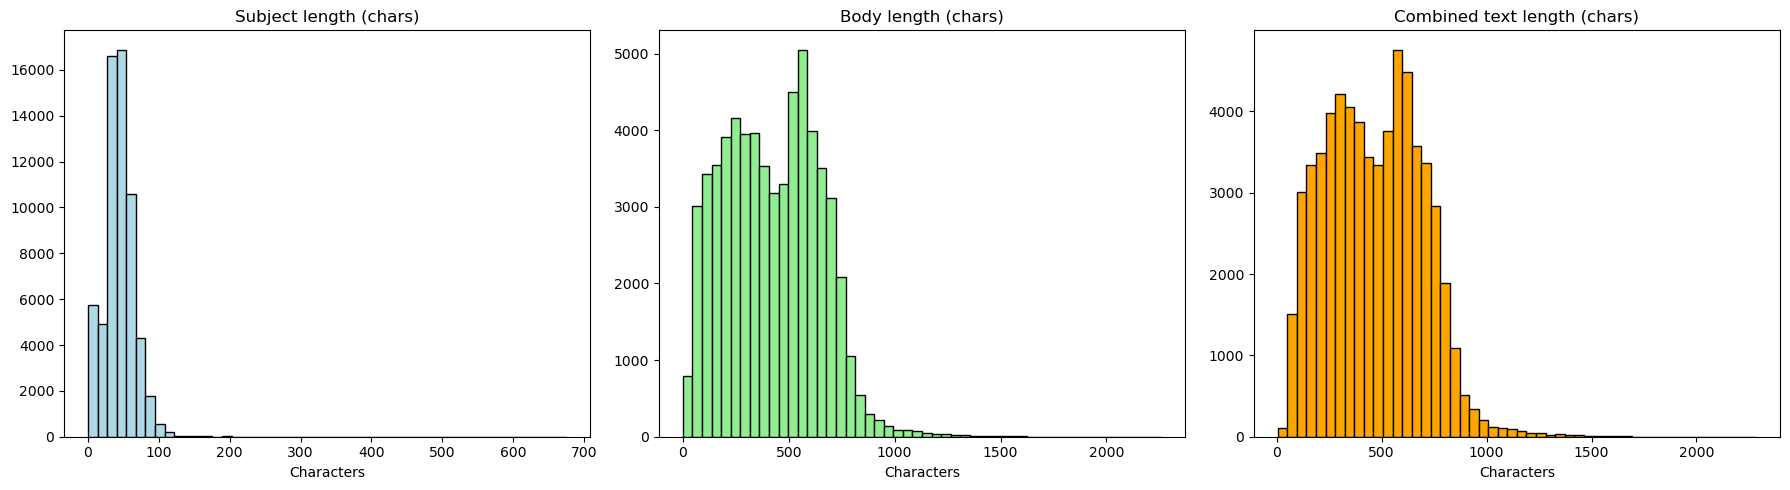

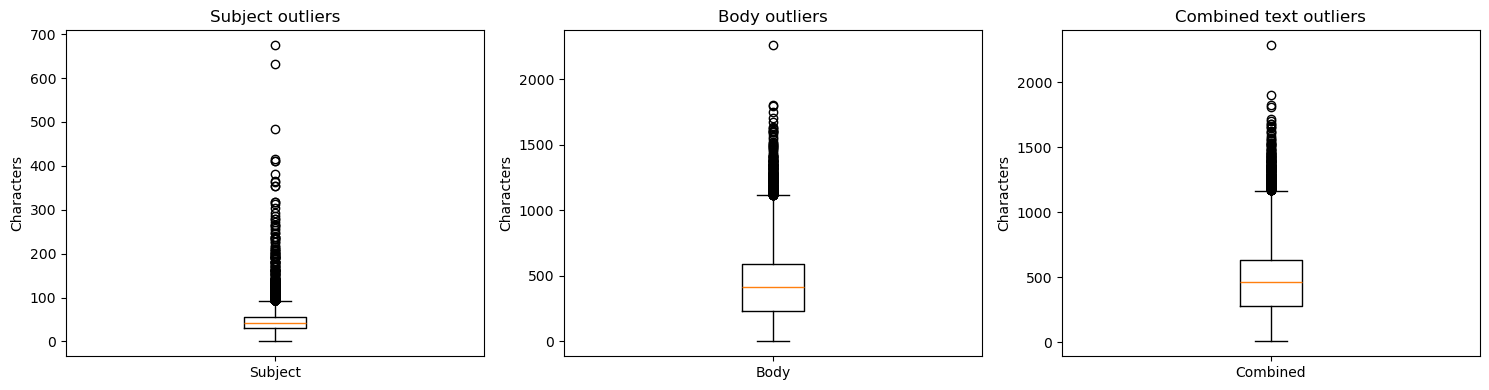


=== Перцентили длин текста (символы) ===
50%: 459 символов
75%: 633 символов
90%: 753 символов
95%: 815 символов
99%: 1000 символов


In [37]:
# Заполняем пропуски в subject пустой строкой
df['subject'] = df['subject'].fillna('')

# Создаём комбинированный текст
df['text'] = df['subject'] + ' ' + df['body']

# Считаем длины (в символах и словах)
df['subject_len_chars'] = df['subject'].str.len()
df['body_len_chars'] = df['body'].str.len()
df['text_len_chars'] = df['text'].str.len()

df['subject_len_words'] = df['subject'].str.split().str.len()
df['body_len_words'] = df['body'].str.split().str.len()
df['text_len_words'] = df['text'].str.split().str.len()

# === Статистика ===
print("=== Длины в символах ===")
print(df[['subject_len_chars', 'body_len_chars', 'text_len_chars']].describe())

print("\n=== Длины в словах ===")
print(df[['subject_len_words', 'body_len_words', 'text_len_words']].describe())

# === Гистограммы (3 в ряд: 1x3) ===
fig_hist, axes_hist = plt.subplots(1, 3, figsize=(18, 5))

axes_hist[0].hist(df['subject_len_chars'], bins=50, color='lightblue', edgecolor='black')
axes_hist[0].set_title('Subject length (chars)')
axes_hist[0].set_xlabel('Characters')

axes_hist[1].hist(df['body_len_chars'], bins=50, color='lightgreen', edgecolor='black')
axes_hist[1].set_title('Body length (chars)')
axes_hist[1].set_xlabel('Characters')

axes_hist[2].hist(df['text_len_chars'], bins=50, color='orange', edgecolor='black')
axes_hist[2].set_title('Combined text length (chars)')
axes_hist[2].set_xlabel('Characters')

plt.tight_layout()
plt.show()

# === Boxplot'ы ===
fig_box, axes_box = plt.subplots(1, 3, figsize=(15, 4))

axes_box[0].boxplot(df['subject_len_chars'].dropna(), tick_labels=['Subject'])
axes_box[0].set_title('Subject outliers')
axes_box[0].set_ylabel('Characters')

axes_box[1].boxplot(df['body_len_chars'].dropna(), tick_labels=['Body'])
axes_box[1].set_title('Body outliers')
axes_box[1].set_ylabel('Characters')

axes_box[2].boxplot(df['text_len_chars'].dropna(), tick_labels=['Combined'])
axes_box[2].set_title('Combined text outliers')
axes_box[2].set_ylabel('Characters')

plt.tight_layout()
plt.show()
# === Перцентили ===
print("\n=== Перцентили длин текста (символы) ===")
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(df['text_len_chars'].dropna(), p)
    print(f"{p}%: {val:.0f} символов")

count    61765.000000
mean       463.509415
std        227.044165
min          5.000000
25%        278.000000
50%        459.000000
75%        633.000000
max       2284.000000
Name: text_len, dtype: float64

=== ДЛИНА ПО СПЛИТАМ ===
         count        mean         std   min    25%    50%    75%     max
split                                                                    
test    6177.0  459.328800  228.550663  17.0  274.0  453.0  629.0  1515.0
train  49412.0  463.754635  226.844163   5.0  279.0  459.0  633.0  2284.0
val     6176.0  465.728789  227.118432  19.0  282.0  462.0  637.0  1677.0

=== ДЛИНА ПО ЯЗЫКАМ ===
            count        mean         std   min    25%    50%    75%     max
language                                                                    
de        33504.0  508.387416  235.989652  14.0  311.0  515.0  703.0  2284.0
en        28261.0  410.305616  203.523559   5.0  245.0  405.0  568.0  1825.0


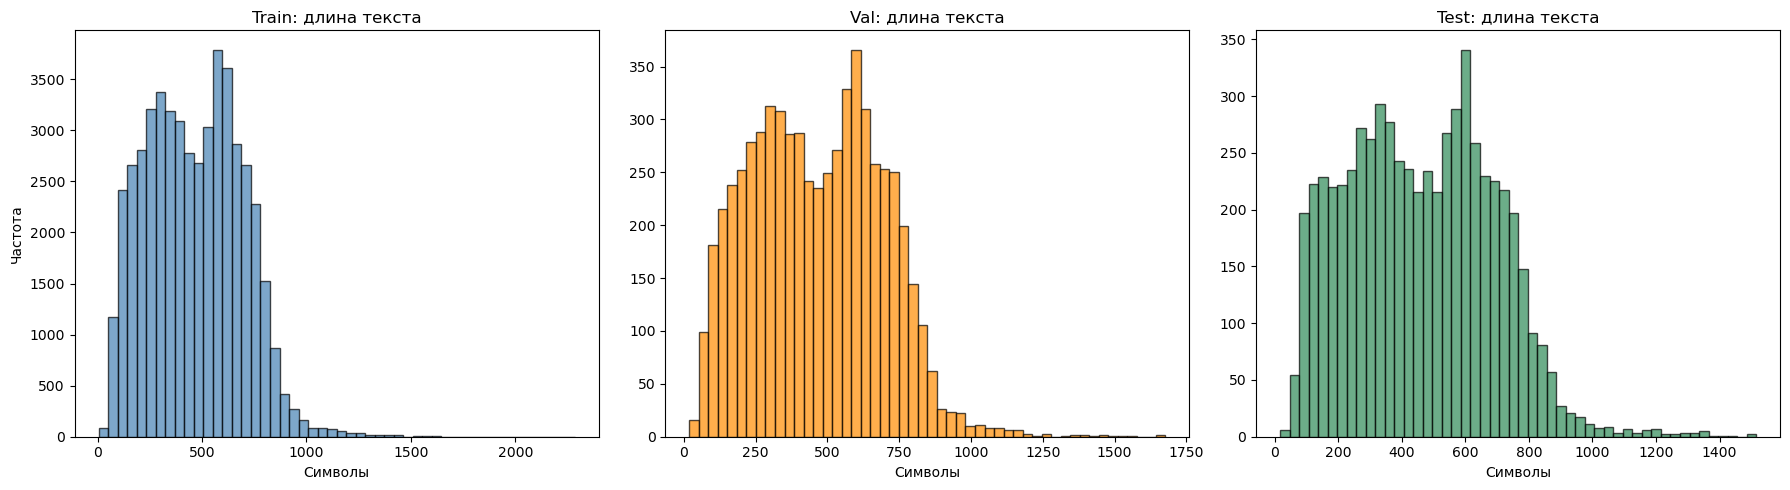

<Figure size 800x500 with 0 Axes>

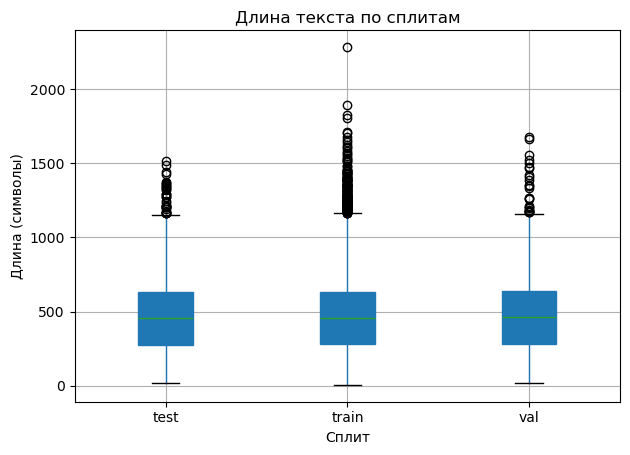


=== ПЕРЦЕНТИЛИ ДЛИНЫ (для выбора max_length) ===
50%: 459 символов
75%: 633 символов
90%: 753 символов
95%: 815 символов
99%: 1000 символов


In [38]:
# Создаём колонку длины
if 'text_len' not in df.columns:
    df['text_len'] = df['text'].str.len()

# 1. Общая статистика
print(df['text_len'].describe())

# 2. Статистика по сплитам
print("\n=== ДЛИНА ПО СПЛИТАМ ===")
print(df.groupby('split')['text_len'].describe())

# 3. Статистика по языкам
print("\n=== ДЛИНА ПО ЯЗЫКАМ ===")
print(df.groupby('language')['text_len'].describe())

# 4. Визуализация: гистограммы
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма для train
axes[0].hist(df[df['split']=='train']['text_len'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Train: длина текста')
axes[0].set_xlabel('Символы')
axes[0].set_ylabel('Частота')

# Гистограмма для val
axes[1].hist(df[df['split']=='val']['text_len'], bins=50, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title('Val: длина текста')
axes[1].set_xlabel('Символы')

# Гистограмма для test
axes[2].hist(df[df['split']=='test']['text_len'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Test: длина текста')
axes[2].set_xlabel('Символы')

plt.tight_layout()
plt.show()

# 5. Boxplot для сравнения распределений
plt.figure(figsize=(8, 5))
df.boxplot(column='text_len', by='split', patch_artist=True)
plt.title('Длина текста по сплитам')
plt.suptitle('')
plt.xlabel('Сплит')
plt.ylabel('Длина (символы)')
plt.tight_layout()
plt.show()

# 6. Перцентили для выбора max_length
print("\n=== ПЕРЦЕНТИЛИ ДЛИНЫ (для выбора max_length) ===")
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(df['text_len'], p)
    print(f"{p}%: {val:.0f} символов")

Средняя длина текста составляет 463 символа (медиана 459), при этом немецкие тикеты заметно длиннее английских (508 vs 410 символов). Распределения длин по сплитам train/val/test схожи, что подтверждает корректность разбиения данных.

### Очистка текста для TF-IDF

In [39]:
# Загружаем stopwords и инициализируем лемматизатор
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Stopwords для английского и немецкого
STOPWORDS_EN = set(stopwords.words('english'))
STOPWORDS_DE = set(stopwords.words('german'))

def clean_text_for_tfidf(text, language='en', use_lemmatization=True, min_word_length=2):
    if not isinstance(text, str):
        return ""

    # Приводим к нижнему регистру
    text = text.lower()

    # Удаляем URL и email
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Удаляем номера телефонов (разные форматы)
    text = re.sub(r'\+?\d[\d\s\-\(\)]{7,}\d', ' ', text)

    # Удаляем хэштеги и упоминания (но оставляем текст после #)
    text = re.sub(r'#(\w+)', r'\1', text)  # #bug -> bug
    text = re.sub(r'@\w+', ' ', text)

    # Удаляем emoji
    text = emoji.replace_emoji(text, replace='')

    # Заменяем переносы строк и лишние пробелы
    text = re.sub(r'\s+', ' ', text)

    # Удаляем HTML теги
    text = re.sub(r'<[^>]+>', ' ', text)

    # Удаляем пунктуацию
    translator = str.maketrans('', '', string.punctuation + '«»""„"…—–-')
    text = text.translate(translator)

    # Определяем stopwords в зависимости от языка
    if language == 'de':
        stop_words = STOPWORDS_DE
    else:  # 'en' или 'auto'
        stop_words = STOPWORDS_EN

    # Токенизация и фильтрация
    words = text.split()
    processed_words = []

    if use_lemmatization:
        # Инициализируем лемматизатор/стеммер
        lemmatizer_en = WordNetLemmatizer()
        stemmer_en = SnowballStemmer('english')
        stemmer_de = SnowballStemmer('german')

        for word in words:
            # Пропускаем stopwords и слишком короткие слова
            if len(word) <= min_word_length:
                continue
            if word in stop_words:
                continue
            # Пропускаем слова с цифрами
            if re.search(r'\d', word):
                continue

            # Лемматизация/стемминг
            if language == 'de':
                # Для немецкого используем стеммер
                processed_word = stemmer_de.stem(word)
            else:
                # Для английского используем лемматизатор
                processed_word = lemmatizer_en.lemmatize(word)
                # Если слово слишком короткое после лемматизации — пропускаем
                if len(processed_word) <= min_word_length:
                    continue

            processed_words.append(processed_word)
    else:
        # Без лемматизации — просто фильтрация
        for word in words:
            if len(word) > min_word_length and word not in stop_words and not re.search(r'\d', word):
                processed_words.append(word)

    return " ".join(processed_words)



**Более мягкая очистка**

In [40]:
def clean_text_soft(text, language='en'):
    """
    Мягкая очистка текста для TF-IDF.
    Сохраняем стоп-слова и исходную форму слов, чтобы не терять контекст и фразы.
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Нижний регистр
    text = text.lower()
    
    # 2. Удаление явного мусора 
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 3. Удаление Emoji 
    text = emoji.replace_emoji(text, replace=' ')
    
    # 4. Замена лишних пробелов и переносов строк на один пробел
    text = re.sub(r'\s+', ' ', text)
    
    # 5. Аккуратная чистка пунктуации. 
    text = re.sub(r'[^\w\säöüß]', ' ', text)
    
    return text.strip()

### SVC + Char N-grams

In [41]:
if 'df_train' not in locals() or 'cleaned_text' not in df_train.columns:
    print("Выполняем предобработку данных...")

    df_train['cleaned_text'] = df_train['subject'].fillna('') + ' ' + df_train['body'].fillna('')
    df_train['cleaned_text'] = df_train['cleaned_text'].apply(clean_text_soft)
    
    df_val['cleaned_text'] = df_val['subject'].fillna('') + ' ' + df_val['body'].fillna('')
    df_val['cleaned_text'] = df_val['cleaned_text'].apply(clean_text_soft)
    

    if 'y_train_queue' not in locals():
        le_queue = LabelEncoder()
        y_train_queue = le_queue.fit_transform(df_train['queue'])
        y_val_queue = le_queue.transform(df_val['queue'])
else:
    print("Применяем мягкую очистку к существующим данным...")
    df_train['cleaned_text'] = df_train['cleaned_text'].apply(clean_text_soft)
    df_val['cleaned_text'] = df_val['cleaned_text'].apply(clean_text_soft)

print(f"Размер Train: {len(df_train)}, Val: {len(df_val)}")
print(f"Пример очищенного текста:\n'{df_train['cleaned_text'].iloc[0][:100]}...'")

print("\nНастройка векторайзеров...")

word_vectorizer = TfidfVectorizer(
    analyzer='word',
    max_features=10000,       
    ngram_range=(1, 2),       
    min_df=2,                 
    max_df=0.95,             
    sublinear_tf=True,        
    dtype=np.float32          
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',       
    max_features=5000,        
    ngram_range=(3, 5),       
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32
)


combined_vectorizer = FeatureUnion([
    ('words', word_vectorizer),
    ('chars', char_vectorizer)
])


start_time = time.time()

X_train_combined = combined_vectorizer.fit_transform(df_train['cleaned_text'])
X_val_combined = combined_vectorizer.transform(df_val['cleaned_text'])

vec_time = time.time() - start_time
print(f"Векторизация завершена за {vec_time:.2f} сек.")

n_words = X_train_combined.shape[1] // 2 

print(f"Итоговая размерность матрицы признаков: {X_train_combined.shape}")
print(f"Количество ненулевых элементов (Train): {X_train_combined.nnz}")
sparsity = 100 * (1 - X_train_combined.nnz / (X_train_combined.shape[0] * X_train_combined.shape[1]))
print(f"Разреженность матрицы: {sparsity:.2f}%")


print("\nОбучение модели LinearSVC...")
start_fit = time.time()

model_svc = LinearSVC(
    C=10.0,                
    class_weight='balanced', 
    max_iter=2000,        
    random_state=42,
    dual=False           
)

model_svc.fit(X_train_combined, y_train_queue)

fit_time = time.time() - start_fit
print(f"Обучение завершено за {fit_time:.2f} сек.")

# ==========================================
# 5. ОЦЕНКА КАЧЕСТВА
# ==========================================
print("\nОценка на валидационной выборке...")
y_pred = model_svc.predict(X_val_combined)

macro_f1 = f1_score(y_val_queue, y_pred, average='macro')
accuracy = accuracy_score(y_val_queue, y_pred)

print("-" * 60)
print("РЕЗУЛЬТАТЫ (Queue Classification)")
print("-" * 60)
print(f"Macro-F1 : {macro_f1:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print("-" * 60)


Применяем мягкую очистку к существующим данным...
Размер Train: 49412, Val: 6176
Пример очищенного текста:
'wesentlicher sicherheitsvorfall sehr geehrtes support team n nich möchte einen gravierenden sicherhe...'

Настройка векторайзеров...
Векторизация завершена за 13.13 сек.
Итоговая размерность матрицы признаков: (49412, 15000)
Количество ненулевых элементов (Train): 30949332
Разреженность матрицы: 95.82%

Обучение модели LinearSVC...
Обучение завершено за 383.01 сек.

Оценка на валидационной выборке...
------------------------------------------------------------
РЕЗУЛЬТАТЫ (Queue Classification)
------------------------------------------------------------
Macro-F1 : 0.8539
Accuracy : 0.5640
------------------------------------------------------------


### Baseline: TF-IDF + линейная модель для queue (macro-F1 и accuracy).

Попробуем с мягкой очисткой 

In [42]:
try:
    stopwords.words('english')
except:
    nltk.download('stopwords', quiet=True)

STOPWORDS_EN = set(stopwords.words('english'))
STOPWORDS_DE = set(stopwords.words('german'))


def process_split(ds, text_col='cleaned_text'):
    df_split = ds.to_pandas()
    # Создаем сырой текст
    df_split['raw_text'] = df_split['subject'].fillna('') + ' ' + df_split['body'].fillna('')

    # Применяем НОВУЮ функцию очистки (без лемматизации и удаления стоп-слов)
    df_split[text_col] = df_split.apply(
        lambda row: clean_text_soft(
            row['raw_text'],
            language=row['language']
        ),
        axis=1
    )
    return df_split

print("Обработка данных с новой функцией очистки (Soft Clean)...")
df_train = process_split(ds_train)
df_val = process_split(ds_val)
df_test = process_split(ds_test)

print(f" Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Пример того, как изменился текст
print("\n--- Пример изменения текста ---")
idx = 0
print(f"Original: {df_train.iloc[idx]['raw_text'][:100]}...")
print(f"Cleaned : {df_train.iloc[idx]['cleaned_text'][:100]}...")
print("-----------------------------\n")

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f" Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),  
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32
)

print("Векторизация TF-IDF...")
X_train = vectorizer.fit_transform(df_train['cleaned_text'])
X_val = vectorizer.transform(df_val['cleaned_text'])

sparsity = 100 * (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]))
print(f" Матрица: {X_train.shape}, разреженность: {sparsity:.1f}%")

# Queue (основная задача)
model_queue = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)
model_queue.fit(X_train, y_train_queue)

# Priority
model_priority = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_priority.fit(X_train, y_train_priority)

# Type
model_type = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_type.fit(X_train, y_train_type)

print(" Модели обучены")

print("\n Оценка на валидации...")

y_val_pred_queue = model_queue.predict(X_val)
y_val_pred_priority = model_priority.predict(X_val)
y_val_pred_type = model_type.predict(X_val)

macro_f1_val = f1_score(y_val_queue, y_val_pred_queue, average='macro')
acc_queue_val = accuracy_score(y_val_queue, y_val_pred_queue)
acc_priority_val = accuracy_score(y_val_priority, y_val_pred_priority)
acc_type_val = accuracy_score(y_val_type, y_val_pred_type)

def calculate_score(f1_q, acc_p, acc_t):
    return 0.70 * f1_q + 0.15 * acc_p + 0.15 * acc_t

final_score = calculate_score(macro_f1_val, acc_priority_val, acc_type_val)

print("\n" + "="*60)
print("BASELINE RESULTS (TF-IDF + LogisticRegression) [SOFT CLEAN]")
print("="*60)
print(f"Queue:    Macro-F1 = {macro_f1_val:.4f} | Accuracy = {acc_queue_val:.4f}")
print(f"Priority: Accuracy = {acc_priority_val:.4f}")
print(f"Type:     Accuracy = {acc_type_val:.4f}")
print("-"*60)
print(f" FINAL SCORE: {final_score:.4f}")
print("="*60)

Обработка данных с новой функцией очистки (Soft Clean)...
 Train: 49412, Val: 6176, Test: 6177

--- Пример изменения текста ---
Original: Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherh...
Cleaned : wesentlicher sicherheitsvorfall sehr geehrtes support team  n nich möchte einen gravierenden sicherh...
-----------------------------

 Классы: queue=52, priority=5, type=5
Векторизация TF-IDF...
 Матрица: (49412, 15000), разреженность: 99.4%
 Модели обучены

 Оценка на валидации...

BASELINE RESULTS (TF-IDF + LogisticRegression) [SOFT CLEAN]
Queue:    Macro-F1 = 0.7279 | Accuracy = 0.4607
Priority: Accuracy = 0.5837
Type:     Accuracy = 0.8507
------------------------------------------------------------
 FINAL SCORE: 0.7247


In [43]:
def process_split(ds, text_col='cleaned_text'):
    df_split = ds.to_pandas()
    df_split['raw_text'] = df_split['subject'].fillna('') + ' ' + df_split['body'].fillna('')

    # Применяем функцию очистки
    df_split[text_col] = df_split.apply(
        lambda row: clean_text_for_tfidf(
            row['raw_text'],
            language=row['language'],
            use_lemmatization=True,
            min_word_length=2
        ),
        axis=1
    )
    return df_split

df_train = process_split(ds_train)
df_val = process_split(ds_val)
df_test = process_split(ds_test)

print(f" Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f" Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")


vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32
)

X_train = vectorizer.fit_transform(df_train['cleaned_text'])
X_val = vectorizer.transform(df_val['cleaned_text'])

# расчёт разреженности
sparsity = 100 * (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]))
print(f" Матрица: {X_train.shape}, разреженность: {sparsity:.1f}%")


# Queue (основная задача)
model_queue = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)
model_queue.fit(X_train, y_train_queue)

# Priority
model_priority = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_priority.fit(X_train, y_train_priority)

# Type
model_type = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_type.fit(X_train, y_train_type)

print(" Модели обучены")

print("\n Оценка на валидации...")

y_val_pred_queue = model_queue.predict(X_val)
y_val_pred_priority = model_priority.predict(X_val)
y_val_pred_type = model_type.predict(X_val)

macro_f1_val = f1_score(y_val_queue, y_val_pred_queue, average='macro')
acc_queue_val = accuracy_score(y_val_queue, y_val_pred_queue)
acc_priority_val = accuracy_score(y_val_priority, y_val_pred_priority)
acc_type_val = accuracy_score(y_val_type, y_val_pred_type)

# Финальный скоринг
def calculate_score(f1_q, acc_p, acc_t):
    return 0.70 * f1_q + 0.15 * acc_p + 0.15 * acc_t

final_score = calculate_score(macro_f1_val, acc_priority_val, acc_type_val)

print("\n" + "="*60)
print("BASELINE RESULTS (TF-IDF + LogisticRegression)")
print("="*60)
print(f"Queue:    Macro-F1 = {macro_f1_val:.4f} | Accuracy = {acc_queue_val:.4f}")
print(f"Priority: Accuracy = {acc_priority_val:.4f}")
print(f"Type:     Accuracy = {acc_type_val:.4f}")
print("-"*60)
print(f" FINAL SCORE: {final_score:.4f}")
print("="*60)



 Train: 49412, Val: 6176, Test: 6177
 Классы: queue=52, priority=5, type=5
 Матрица: (49412, 15000), разреженность: 99.7%
 Модели обучены

 Оценка на валидации...

BASELINE RESULTS (TF-IDF + LogisticRegression)
Queue:    Macro-F1 = 0.7217 | Accuracy = 0.4658
Priority: Accuracy = 0.5806
Type:     Accuracy = 0.8504
------------------------------------------------------------
 FINAL SCORE: 0.7198


Создадим табличку для сравнения потом моделей

In [44]:
def create_results_table():

    df_results = pd.DataFrame(columns=[
        'accuracy_queue',
        'f1_macro_queue',
        'accuracy_priority',
        'accuracy_type',
        'final_score'
    ])
    return df_results


def add_model_result(df_results, model_name,
                     acc_queue, f1_macro_queue,
                     acc_priority, acc_type):

    # Считаем итоговый скоринг
    final_score = 0.70 * f1_macro_queue + 0.15 * acc_priority + 0.15 * acc_type

    # Проверяем, есть ли уже такая модель
    if model_name in df_results.index:
        print(f" Модель '{model_name}' уже существует! Обновляем...")
        df_results = df_results.drop(model_name)

    # Создаём новую строку
    new_row = pd.DataFrame({
        'accuracy_queue': [round(acc_queue, 4)],
        'f1_macro_queue': [round(f1_macro_queue, 4)],
        'accuracy_priority': [round(acc_priority, 4)],
        'accuracy_type': [round(acc_type, 4)],
        'final_score': [round(final_score, 4)]
    }, index=[model_name])

    # Добавляем в таблицу
    df_results = pd.concat([df_results, new_row])

    print(f"   Final Score: {final_score:.4f}")

    return df_results


def show_results(df_results):

    # Сортируем по итоговому скору
    df_sorted = df_results.sort_values('final_score', ascending=True)
    # Округляем для красоты
    df_display = df_sorted.round(4)
    print("="*80)
    print(df_display.to_string())

    # Показываем лучшую
    best = df_results.sort_values('final_score', ascending=False).head(1)
    print(f"\n Лучшая модель: {best.index[0]} (Score: {best['final_score'].values[0]:.4f})")

    return df_display

In [45]:
df_results = create_results_table()
df_results = add_model_result(
    df_results=df_results,
    model_name='TF-IDF + LogisticRegression',
    acc_queue=acc_queue_val,
    f1_macro_queue=macro_f1_val,
    acc_priority=acc_priority_val,
    acc_type=acc_type_val
)
df_results

   Final Score: 0.7198


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198


### WORD2VEC: Минимальная очистка и токенизация

In [12]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\S+@\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')  # оставляем текст после #
MULTISPACE_RE = re.compile(r'\s+')

# Токенизация: оставляем буквы (включая немецкие umlauts) и цифры
TOKEN_RE = re.compile(r'[a-zäöüß0-9]+', re.IGNORECASE)


def clean_text_w2v(text: str) -> str:
    """Минимальная очистка для Word2Vec."""
    if not isinstance(text, str):
        return ""

    text = text.replace("\n", " ")
    text = text.replace("<br />", " ")  # HTML переносы
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(r'\1', text)  # #bug -> bug
    text = text.lower()
    text = MULTISPACE_RE.sub(" ", text).strip()

    return text

def tokenize_text(text: str):
    """Простая токенизация: буквы + цифры."""
    return TOKEN_RE.findall(text.lower())


print("Очистка и токенизация текстов...")

for df_split in [df_train, df_val, df_test]:
    # Исходный текст
    df_split['raw_text'] = df_split['subject'].fillna('') + ' ' + df_split['body'].fillna('')

    # Очистка
    df_split['text_clean'] = df_split['raw_text'].map(clean_text_w2v)

    # Токенизация
    df_split['tokens'] = df_split['text_clean'].map(tokenize_text)

print(f"Пример очистки:")
print(f"  Оригинал: {df_train['raw_text'].iloc[0][:100]}...")
print(f"  Очищено:  {df_train['text_clean'].iloc[0][:100]}...")
print(f"  Токены:   {df_train['tokens'].iloc[0][:10]}")


print("ОБУЧЕНИЕ WORD2VEC")

start_time = time.time()

# Параметры (адаптированы для нашего корпуса)
W2V_PARAMS = {
    'vector_size': 100,
    'window': 5,
    'min_count': 5,          # игнорируем очень редкие слова
    'workers': 4,
    'sg': 1,                 # Skip-gram
    'epochs': 10
}

# Обучаем на train + val для большего словаря
all_tokens = df_train['tokens'].tolist() + df_val['tokens'].tolist()

model_w2v = Word2Vec(
    sentences=all_tokens,
    **W2V_PARAMS
)

training_time = time.time() - start_time
print(f" Word2Vec обучен за {training_time:.1f} сек")
print(f"   Словарь: {len(model_w2v.wv)} слов")
print(f"   Размерность: {model_w2v.vector_size}")


def text_to_vector(tokens, model, vector_size=100):
    """Среднее векторов всех слов в документе."""
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)

print("\nСоздание документных векторов...")

X_train = np.array([text_to_vector(tokens, model_w2v) for tokens in df_train['tokens']])
X_val = np.array([text_to_vector(tokens, model_w2v) for tokens in df_val['tokens']])
X_test = np.array([text_to_vector(tokens, model_w2v) for tokens in df_test['tokens']])

print(f"Матрица признаков: {X_train.shape}")


le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))


print("\nОбучение классификаторов...")

model_queue = LogisticRegression(
    max_iter=1000, class_weight='balanced', solver='lbfgs', n_jobs=-1, random_state=42
)
model_queue.fit(X_train, y_train_queue)

model_priority = LogisticRegression(
    max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1
)
model_priority.fit(X_train, y_train_priority)

model_type = LogisticRegression(
    max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1
)
model_type.fit(X_train, y_train_type)

print("✅ Модели обучены")

y_val_pred_queue = model_queue.predict(X_val)
y_val_pred_priority = model_priority.predict(X_val)
y_val_pred_type = model_type.predict(X_val)

macro_f1_val = f1_score(y_val_queue, y_val_pred_queue, average='macro')
acc_queue_val = accuracy_score(y_val_queue, y_val_pred_queue)
acc_priority_val = accuracy_score(y_val_priority, y_val_pred_priority)
acc_type_val = accuracy_score(y_val_type, y_val_pred_type)

final_score = 0.70 * macro_f1_val + 0.15 * acc_priority_val + 0.15 * acc_type_val


print("WORD2VEC RESULTS (Validation)")

print(f"Queue:    Macro-F1 = {macro_f1_val:.4f} | Accuracy = {acc_queue_val:.4f}")
print(f"Priority: Accuracy = {acc_priority_val:.4f}")
print(f"Type:     Accuracy = {acc_type_val:.4f}")
print("-"*60)
print(f" FINAL SCORE: {final_score:.4f}")
print(f" Время обучения: {training_time:.1f} сек")
print("="*60)

df_results = add_model_result(
    df_results=df_results,
    model_name='Word2Vec (min_clean) + LR',
    acc_queue=acc_queue_val,
    f1_macro_queue=macro_f1_val,
    acc_priority=acc_priority_val,
    acc_type=acc_type_val
)

# Показать сравнение с TF-IDF
show_results(df_results)

Очистка и токенизация текстов...
Пример очистки:
  Оригинал: Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherh...
  Очищено:  wesentlicher sicherheitsvorfall sehr geehrtes support-team,\n\nich möchte einen gravierenden sicherh...
  Токены:   ['wesentlicher', 'sicherheitsvorfall', 'sehr', 'geehrtes', 'support', 'team', 'n', 'nich', 'möchte', 'einen']
ОБУЧЕНИЕ WORD2VEC


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


 Word2Vec обучен за 25.0 сек
   Словарь: 13997 слов
   Размерность: 100

Создание документных векторов...
Матрица признаков: (49412, 100)

Обучение классификаторов...
✅ Модели обучены
WORD2VEC RESULTS (Validation)
Queue:    Macro-F1 = 0.4735 | Accuracy = 0.3093
Priority: Accuracy = 0.4594
Type:     Accuracy = 0.8125
------------------------------------------------------------
 FINAL SCORE: 0.5222
 Время обучения: 25.0 сек
   Final Score: 0.5222
                             accuracy_queue  f1_macro_queue  accuracy_priority  accuracy_type  final_score
Word2Vec (min_clean) + LR            0.3093          0.4735             0.4594         0.8125       0.5222
TF-IDF + LogisticRegression          0.4658          0.7217             0.5806         0.8504       0.7198

 Лучшая модель: TF-IDF + LogisticRegression (Score: 0.7198)


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198


52 класса — нужно много специфичных сигналов \
TF-IDF с биграммами ловит фразы: "password reset", "billing error", "return label" \
Word2Vec усредняет векторы слов → теряет точные маркеры класса

### Transformer fine-tuning на multitask (queue, priority, type)

Прежде чем перейти к полноценному fine-tuning, попробуем использовать предобученный BERT как фиксированный экстрактор признаков, обучая только новые классификационные головы. Это позволит оценить, насколько хорошо "замороженные" эмбеддинги BERT справляются с нашей задачей без дообучения под специфику данных.

**xlm-roberta-base**

In [ ]:
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

print("="*60)
print("TRANSFORMER MULTI-TASK (FIXED)")
print("="*60)

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_WORKERS = 0

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}

print(f"\nМодель: {MODEL_NAME}")
print(f"Max length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

# ==========================================
# 2. ТОКЕНИЗАТОР
# ==========================================
print("\nЗагрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ''
    body = str(row['body']) if pd.notna(row['body']) else ''
    return (subject + ' ' + body).strip()

df_train['text'] = df_train.apply(prepare_text, axis=1)
df_val['text'] = df_val.apply(prepare_text, axis=1)

print(f"Пример: {df_train['text'].iloc[0][:100]}...")

# ==========================================
# 3. КОДИРОВАНИЕ ЛЕЙБЛОВ
# ==========================================
print("\nКодирование лейблов...")

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f"Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")

# ==========================================
# 4. DATASET
# ==========================================
class MultiTaskDataset(Dataset):
    def __init__(self, texts, labels_queue, labels_priority, labels_type, tokenizer, max_length):
        self.texts = texts
        self.labels_queue = labels_queue
        self.labels_priority = labels_priority
        self.labels_type = labels_type
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.labels_queue[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.labels_priority[idx], dtype=torch.long),
            'type_label': torch.tensor(self.labels_type[idx], dtype=torch.long),
        }

print("\nСоздание Dataset...")
train_dataset = MultiTaskDataset(
    df_train['text'].tolist(),
    y_train_queue,
    y_train_priority,
    y_train_type,
    tokenizer,
    MAX_LENGTH
)
val_dataset = MultiTaskDataset(
    df_val['text'].tolist(),
    y_val_queue,
    y_val_priority,
    y_val_type,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# ==========================================
# 5. МОДЕЛЬ
# ==========================================
class MultiTaskTransformer(nn.Module):
    def __init__(self, model_name, num_queue=52, num_priority=5, num_type=5):
        super(MultiTaskTransformer, self).__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.3)

        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        queue_logits = self.queue_head(cls_output)
        priority_logits = self.priority_head(cls_output)
        type_logits = self.type_head(cls_output)

        return {
            'queue_logits': queue_logits,
            'priority_logits': priority_logits,
            'type_logits': type_logits
        }

model = MultiTaskTransformer(
    MODEL_NAME,
    len(le_queue.classes_),
    len(le_priority.classes_),
    len(le_type.classes_)
)
model.to(device)

print(f"\nПараметры: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 6. ОПТИМИЗАТОР
# ==========================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 7. ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ
# ==========================================
def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} Train")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        queue_labels = batch['queue_label'].to(device)
        priority_labels = batch['priority_label'].to(device)
        type_labels = batch['type_label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss_queue = criterion(outputs['queue_logits'], queue_labels)
        loss_priority = criterion(outputs['priority_logits'], priority_labels)
        loss_type = criterion(outputs['type_logits'], type_labels)

        total_batch_loss = (
            LOSS_WEIGHTS['queue'] * loss_queue +
            LOSS_WEIGHTS['priority'] * loss_priority +
            LOSS_WEIGHTS['type'] * loss_type
        )

        total_batch_loss.backward()
        optimizer.step()

        total_loss += total_batch_loss.item()
        pbar.set_postfix({'loss': f'{total_batch_loss.item():.4f}'})

    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_queue_logits = []
    all_priority_logits = []
    all_type_logits = []
    all_queue_labels = []
    all_priority_labels = []
    all_type_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            queue_labels = batch['queue_label'].to(device)
            priority_labels = batch['priority_label'].to(device)
            type_labels = batch['type_label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            all_queue_logits.append(outputs['queue_logits'].cpu())
            all_priority_logits.append(outputs['priority_logits'].cpu())
            all_type_logits.append(outputs['type_logits'].cpu())
            all_queue_labels.append(queue_labels.cpu())
            all_priority_labels.append(priority_labels.cpu())
            all_type_labels.append(type_labels.cpu())

    queue_logits = torch.cat(all_queue_logits, dim=0).numpy()
    priority_logits = torch.cat(all_priority_logits, dim=0).numpy()
    type_logits = torch.cat(all_type_logits, dim=0).numpy()
    queue_labels = torch.cat(all_queue_labels, dim=0).numpy()
    priority_labels = torch.cat(all_priority_labels, dim=0).numpy()
    type_labels = torch.cat(all_type_labels, dim=0).numpy()

    queue_preds = np.argmax(queue_logits, axis=1)
    priority_preds = np.argmax(priority_logits, axis=1)
    type_preds = np.argmax(type_logits, axis=1)

    macro_f1_queue = f1_score(queue_labels, queue_preds, average='macro')
    acc_queue = accuracy_score(queue_labels, queue_preds)
    acc_priority = accuracy_score(priority_labels, priority_preds)
    acc_type = accuracy_score(type_labels, type_preds)

    final_score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    return {
        'macro_f1_queue': macro_f1_queue,
        'accuracy_queue': acc_queue,
        'accuracy_priority': acc_priority,
        'accuracy_type': acc_type,
        'final_score': final_score
    }

# ==========================================
# 8. ЦИКЛ ОБУЧЕНИЯ
# ==========================================
print("НАЧАЛО ОБУЧЕНИЯ")


start_time = time.time()
best_score = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")
    print('='*60)

    train_loss = train_epoch(model, train_loader, optimizer, device, epoch)
    print(f"Train Loss: {train_loss:.4f}")

    eval_results = evaluate(model, val_loader, device)
    print(f"Queue:    Macro-F1 = {eval_results['macro_f1_queue']:.4f} | Accuracy = {eval_results['accuracy_queue']:.4f}")
    print(f"Priority: Accuracy = {eval_results['accuracy_priority']:.4f}")
    print(f"Type:     Accuracy = {eval_results['accuracy_type']:.4f}")
    print(f"Final Score: {eval_results['final_score']:.4f}")

    if eval_results['final_score'] > best_score:
        best_score = eval_results['final_score']
        best_model_state = model.state_dict().copy()
        print(f"Новая лучшая модель! Score: {best_score:.4f}")

training_time = time.time() - start_time


print("\n" + "="*60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

final_results = evaluate(model, val_loader, device)

print(f"Queue:    Macro-F1 = {final_results['macro_f1_queue']:.4f} | Accuracy = {final_results['accuracy_queue']:.4f}")
print(f"Priority: Accuracy = {final_results['accuracy_priority']:.4f}")
print(f"Type:     Accuracy = {final_results['accuracy_type']:.4f}")
print("-"*60)
print(f"FINAL SCORE: {final_results['final_score']:.4f}")
print(f"Время обучения: {training_time/60:.1f} мин")
print("="*60)


print("\nСохранение результатов...")

results_df = pd.DataFrame({
    'Model': ['XLM-RoBERTa Multi-Task'],
    'Macro-F1 (queue)': [final_results['macro_f1_queue']],
    'Accuracy (queue)': [final_results['accuracy_queue']],
    'Accuracy (priority)': [final_results['accuracy_priority']],
    'Accuracy (type)': [final_results['accuracy_type']],
    'Final Score': [final_results['final_score']],
    'Training Time (min)': [training_time/60]
})

results_df.to_csv('transformer_results.csv', index=False)
print("Результаты сохранены в transformer_results.csv")

torch.save({
    'model_state_dict': model.state_dict(),
    'le_queue': le_queue,
    'le_priority': le_priority,
    'le_type': le_type,
}, 'model_checkpoint.pth')
print("Модель сохранена в model_checkpoint.pth")


🤖 TRANSFORMER MULTI-TASK (FIXED)
📍 Device: cuda
🎮 GPU: Tesla T4

🤖 Модель: xlm-roberta-base
📏 Max length: 256
📦 Batch size: 16
🔄 Epochs: 3

📝 Загрузка токенизатора...
Пример: Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherh...

🏷️ Кодирование лейблов...
Классы: queue=52, priority=5, type=5

📦 Создание Dataset...
Train batches: 3089, Val batches: 193


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🏗️ Параметры: 278,091,326

🚀 НАЧАЛО ОБУЧЕНИЯ

EPOCH 1/3


Epoch 1 Train: 100%|██████████| 3089/3089 [39:29<00:00,  1.30it/s, loss=1.0127]


...

Train Loss: 1.0115


Evaluating: 100%|██████████| 193/193 [01:28<00:00,  2.19it/s]


Queue:    Macro-F1 = 0.8416 | Accuracy = 0.5727
Priority: Accuracy = 0.5622
Type:     Accuracy = 0.8486
Final Score: 0.8007
💾 Новая лучшая модель! Score: 0.8007

📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ


Evaluating: 100%|██████████| 193/193 [01:28<00:00,  2.19it/s]


Queue:    Macro-F1 = 0.8416 | Accuracy = 0.5727
Priority: Accuracy = 0.5622
Type:     Accuracy = 0.8486
------------------------------------------------------------
🏆 FINAL SCORE: 0.8007
⏱️  Время обучения: 123.0 мин

💾 Сохранение результатов...
✅ Результаты сохранены в transformer_results.csv
✅ Модель сохранена в model_checkpoint.pth

✅ ВСЁ ЗАВЕРШЕНО УСПЕШНО!


In [13]:
df_results = add_model_result(
    df_results=df_results,
    model_name='XLM-RoBERTa (feature extractor)',
    acc_queue=0.5727,
    f1_macro_queue=0.8416,
    acc_priority=0.5622,
    acc_type=0.8486
)

df_results

   Final Score: 0.8007


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
XLM-RoBERTa (feature extractor),0.5727,0.8416,0.5622,0.8486,0.8007


In [ ]:
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

print("="*60)
print("TRANSFORMER MULTI-TASK (FINE-TUNING)")
print("="*60)

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ==========================================
# 1. НАСТРОЙКИ
# ==========================================
MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_WORKERS = 0

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}

print(f"\nМодель: {MODEL_NAME}")
print(f"Max length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

# ==========================================
# 2. ТОКЕНИЗАТОР
# ==========================================
print("\nЗагрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ''
    body = str(row['body']) if pd.notna(row['body']) else ''
    return (subject + ' ' + body).strip()

df_train['text'] = df_train.apply(prepare_text, axis=1)
df_val['text'] = df_val.apply(prepare_text, axis=1)

print(f"Пример: {df_train['text'].iloc[0][:100]}...")

# ==========================================
# 3. КОДИРОВАНИЕ ЛЕЙБЛОВ
# ==========================================
print("\nКодирование лейблов...")

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f"Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")

# ==========================================
# 4. DATASET
# ==========================================
class MultiTaskDataset(Dataset):
    def __init__(self, texts, labels_queue, labels_priority, labels_type, tokenizer, max_length):
        self.texts = texts
        self.labels_queue = labels_queue
        self.labels_priority = labels_priority
        self.labels_type = labels_type
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.labels_queue[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.labels_priority[idx], dtype=torch.long),
            'type_label': torch.tensor(self.labels_type[idx], dtype=torch.long),
        }

print("\nСоздание Dataset...")
train_dataset = MultiTaskDataset(
    df_train['text'].tolist(),
    y_train_queue,
    y_train_priority,
    y_train_type,
    tokenizer,
    MAX_LENGTH
)
val_dataset = MultiTaskDataset(
    df_val['text'].tolist(),
    y_val_queue,
    y_val_priority,
    y_val_type,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# ==========================================
# 5. МОДЕЛЬ
# ==========================================
class MultiTaskTransformer(nn.Module):
    def __init__(self, model_name, num_queue=52, num_priority=5, num_type=5):
        super(MultiTaskTransformer, self).__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.3)

        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        queue_logits = self.queue_head(cls_output)
        priority_logits = self.priority_head(cls_output)
        type_logits = self.type_head(cls_output)

        return {
            'queue_logits': queue_logits,
            'priority_logits': priority_logits,
            'type_logits': type_logits
        }

# Создание модели
model = MultiTaskTransformer(
    MODEL_NAME,
    len(le_queue.classes_),
    len(le_priority.classes_),
    len(le_type.classes_)
)
model.to(device)

print(f"\nПараметры: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 6. ОПТИМИЗАТОР
# ==========================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 7. ФУНКЦИИ ОБУЧЕНИЯ
# ==========================================
def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} Train")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        queue_labels = batch['queue_label'].to(device)
        priority_labels = batch['priority_label'].to(device)
        type_labels = batch['type_label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss_queue = criterion(outputs['queue_logits'], queue_labels)
        loss_priority = criterion(outputs['priority_logits'], priority_labels)
        loss_type = criterion(outputs['type_logits'], type_labels)

        total_batch_loss = (
            LOSS_WEIGHTS['queue'] * loss_queue +
            LOSS_WEIGHTS['priority'] * loss_priority +
            LOSS_WEIGHTS['type'] * loss_type
        )

        total_batch_loss.backward()
        optimizer.step()

        total_loss += total_batch_loss.item()
        pbar.set_postfix({'loss': f'{total_batch_loss.item():.4f}'})

    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_queue_logits = []
    all_priority_logits = []
    all_type_logits = []
    all_queue_labels = []
    all_priority_labels = []
    all_type_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            queue_labels = batch['queue_label'].to(device)
            priority_labels = batch['priority_label'].to(device)
            type_labels = batch['type_label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            all_queue_logits.append(outputs['queue_logits'].cpu())
            all_priority_logits.append(outputs['priority_logits'].cpu())
            all_type_logits.append(outputs['type_logits'].cpu())
            all_queue_labels.append(queue_labels.cpu())
            all_priority_labels.append(priority_labels.cpu())
            all_type_labels.append(type_labels.cpu())

    queue_logits = torch.cat(all_queue_logits, dim=0).numpy()
    priority_logits = torch.cat(all_priority_logits, dim=0).numpy()
    type_logits = torch.cat(all_type_logits, dim=0).numpy()
    queue_labels = torch.cat(all_queue_labels, dim=0).numpy()
    priority_labels = torch.cat(all_priority_labels, dim=0).numpy()
    type_labels = torch.cat(all_type_labels, dim=0).numpy()

    queue_preds = np.argmax(queue_logits, axis=1)
    priority_preds = np.argmax(priority_logits, axis=1)
    type_preds = np.argmax(type_logits, axis=1)

    macro_f1_queue = f1_score(queue_labels, queue_preds, average='macro')
    acc_queue = accuracy_score(queue_labels, queue_preds)
    acc_priority = accuracy_score(priority_labels, priority_preds)
    acc_type = accuracy_score(type_labels, type_preds)

    final_score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    return {
        'macro_f1_queue': macro_f1_queue,
        'accuracy_queue': acc_queue,
        'accuracy_priority': acc_priority,
        'accuracy_type': acc_type,
        'final_score': final_score
    }

# ==========================================
# 8. ЦИКЛ ОБУЧЕНИЯ
# ==========================================
print("\n" + "="*60)
print("НАЧАЛО FINE-TUNING")
print("="*60)

start_time = time.time()
best_score = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")
    print('='*60)

    train_loss = train_epoch(model, train_loader, optimizer, device, epoch)
    print(f"Train Loss: {train_loss:.4f}")

    eval_results = evaluate(model, val_loader, device)
    print(f"Queue:    Macro-F1 = {eval_results['macro_f1_queue']:.4f} | Accuracy = {eval_results['accuracy_queue']:.4f}")
    print(f"Priority: Accuracy = {eval_results['accuracy_priority']:.4f}")
    print(f"Type:     Accuracy = {eval_results['accuracy_type']:.4f}")
    print(f"Final Score: {eval_results['final_score']:.4f}")

    if eval_results['final_score'] > best_score:
        best_score = eval_results['final_score']
        best_model_state = model.state_dict().copy()
        print(f"Новая лучшая модель! Score: {best_score:.4f}")

training_time = time.time() - start_time

# ==========================================
# 9. ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
# ==========================================
print("\n" + "="*60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

final_results = evaluate(model, val_loader, device)

print(f"Queue:    Macro-F1 = {final_results['macro_f1_queue']:.4f}")
print(f"Priority: Accuracy = {final_results['accuracy_priority']:.4f}")
print(f"Type:     Accuracy = {final_results['accuracy_type']:.4f}")
print("-"*60)
print(f"FINAL SCORE: {final_results['final_score']:.4f}")
print(f"Время Fine-Tuning: {training_time/60:.1f} мин")
print("="*60)

# ==========================================
# 10. СОХРАНЕНИЕ
# ==========================================
print("\nСохранение результатов...")

results_df = pd.DataFrame({
    'Model': ['XLM-RoBERTa Multi-Task (Fine-Tuned)'],
    'Macro-F1 (queue)': [final_results['macro_f1_queue']],
    'Accuracy (queue)': [final_results['accuracy_queue']],
    'Accuracy (priority)': [final_results['accuracy_priority']],
    'Accuracy (type)': [final_results['accuracy_type']],
    'Final Score': [final_results['final_score']],
    'Training Time (min)': [training_time/60]
})

results_df.to_csv('transformer_results.csv', index=False)
print("Результаты сохранены в transformer_results.csv")

torch.save({
    'model_state_dict': model.state_dict(),
    'le_queue': le_queue,
    'le_priority': le_priority,
    'le_type': le_type,
}, 'model_checkpoint.pth')
print("Модель сохранена в model_checkpoint.pth")

print("\n" + "="*60)
print("FINE-TUNING ЗАВЕРШЁН")
print(f"\nFinal Score: {final_results['final_score']:.4f}")


TRANSFORMER MULTI-TASK (FINE-TUNING)
Device: cuda
GPU: Tesla T4

Модель: xlm-roberta-base
Max length: 256
Batch size: 16
Epochs: 3

Загрузка токенизатора...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 2 Train: 100%|██████████| 3089/3089 [44:33<00:00,  1.16it/s, loss=0.4010]


Train Loss: 1.1383


Evaluating: 100%|██████████| 193/193 [01:43<00:00,  1.87it/s]


Queue:    Macro-F1 = 0.8133 | Accuracy = 0.5609
Priority: Accuracy = 0.5382
Type:     Accuracy = 0.8431
Final Score: 0.7765
Новая лучшая модель! Score: 0.7765

EPOCH 3/3


Epoch 3 Train:  44%|████▍     | 1360/3089 [19:36<25:04,  1.15it/s, loss=0.9143]

In [14]:
df_results = add_model_result(
    df_results=df_results,
    model_name='XLM-RoBERTa (fine-tuning)',
    acc_queue=0.5609,
    f1_macro_queue=0.8133,
    acc_priority=0.5382,
    acc_type=0.8431
)

df_results

   Final Score: 0.7765


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
XLM-RoBERTa (feature extractor),0.5727,0.8416,0.5622,0.8486,0.8007
XLM-RoBERTa (fine-tuning),0.5609,0.8133,0.5382,0.8431,0.7765


**sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2**

Сначала пробуем без fine-tuning

In [12]:
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

print("="*60)
print("⚡ MINILM MULTI-TASK (САМЫЙ БЫСТРЫЙ)")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📍 Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_LENGTH = 128
BATCH_SIZE = 64
NUM_EPOCHS = 2
LEARNING_RATE = 5e-5
NUM_WORKERS = 0

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}

print(f"\nМодель: {MODEL_NAME}")
print(f"Max length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")


print("\n Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ''
    body = str(row['body']) if pd.notna(row['body']) else ''
    return (subject + ' ' + body).strip()

df_train['text'] = df_train.apply(prepare_text, axis=1)
df_val['text'] = df_val.apply(prepare_text, axis=1)

print(f"Пример: {df_train['text'].iloc[0][:80]}...")


print("\n Кодирование лейблов...")

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f"Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")


class MultiTaskDataset(Dataset):
    def __init__(self, texts, lq, lp, lt, tokenizer, max_len):
        self.texts = texts
        self.lq = lq
        self.lp = lp
        self.lt = lt
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.lq[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.lp[idx], dtype=torch.long),
            'type_label': torch.tensor(self.lt[idx], dtype=torch.long),
        }

print("\n Создание Dataset...")
train_dataset = MultiTaskDataset(df_train['text'].tolist(), y_train_queue, y_train_priority, y_train_type, tokenizer, MAX_LENGTH)
val_dataset = MultiTaskDataset(df_val['text'].tolist(), y_val_queue, y_val_priority, y_val_type, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

class MiniLMMultiTask(nn.Module):
    def __init__(self, model_name, nq, np, nt):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.3)
        self.queue_head = nn.Linear(hidden, nq)
        self.priority_head = nn.Linear(hidden, np)
        self.type_head = nn.Linear(hidden, nt)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return {
            'queue_logits': self.queue_head(cls),
            'priority_logits': self.priority_head(cls),
            'type_logits': self.type_head(cls),
        }

model = MiniLMMultiTask(MODEL_NAME, len(le_queue.classes_), len(le_priority.classes_), len(le_type.classes_))
model.to(device)

print(f"\n Параметры: {sum(p.numel() for p in model.parameters()):,}")


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ql = batch['queue_label'].to(device)
        pl = batch['priority_label'].to(device)
        tl = batch['type_label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss = (LOSS_WEIGHTS['queue'] * criterion(outputs['queue_logits'], ql) +
                LOSS_WEIGHTS['priority'] * criterion(outputs['priority_logits'], pl) +
                LOSS_WEIGHTS['type'] * criterion(outputs['type_logits'], tl))

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_ql, all_pl, all_tl = [], [], []
    all_qt, all_pt, all_tt = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ql = batch['queue_label'].to(device)
            pl = batch['priority_label'].to(device)
            tl = batch['type_label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            all_ql.append(ql.cpu()); all_pl.append(pl.cpu()); all_tl.append(tl.cpu())
            all_qt.append(outputs['queue_logits'].cpu())
            all_pt.append(outputs['priority_logits'].cpu())
            all_tt.append(outputs['type_logits'].cpu())

    ql = torch.cat(all_ql).numpy(); pl = torch.cat(all_pl).numpy(); tl = torch.cat(all_tl).numpy()
    qt = torch.cat(all_qt).numpy(); pt = torch.cat(all_pt).numpy(); tt = torch.cat(all_tt).numpy()

    qp = np.argmax(qt, axis=1); pp = np.argmax(pt, axis=1); tp = np.argmax(tt, axis=1)

    f1 = f1_score(ql, qp, average='macro')
    aq = accuracy_score(ql, qp)
    ap = accuracy_score(pl, pp)
    at = accuracy_score(tl, tp)
    score = 0.70 * f1 + 0.15 * ap + 0.15 * at

    return {'macro_f1_queue': f1, 'accuracy_queue': aq, 'accuracy_priority': ap, 'accuracy_type': at, 'final_score': score}

print("\n" + "="*60)
print(" НАЧАЛО ОБУЧЕНИЯ")
print("="*60)

start_time = time.time()
best_score = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}\nEPOCH {epoch+1}/{NUM_EPOCHS}\n{'='*60}")

    train_loss = train_epoch(model, train_loader, optimizer, device, epoch)
    print(f"Train Loss: {train_loss:.4f}")

    eval_res = evaluate(model, val_loader, device)
    print(f"Queue:    Macro-F1 = {eval_res['macro_f1_queue']:.4f} | Acc = {eval_res['accuracy_queue']:.4f}")
    print(f"Priority: Acc = {eval_res['accuracy_priority']:.4f}")
    print(f"Type:     Acc = {eval_res['accuracy_type']:.4f}")
    print(f"Final Score: {eval_res['final_score']:.4f}")

    if eval_res['final_score'] > best_score:
        best_score = eval_res['final_score']
        best_state = model.state_dict().copy()
        print(f"💾 Лучшая модель! Score: {best_score:.4f}")

training_time = time.time() - start_time


print("\n" + "="*60)
print(" ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

if best_state:
    model.load_state_dict(best_state)

final = evaluate(model, val_loader, device)

print(f"Queue:    Macro-F1 = {final['macro_f1_queue']:.4f} | Acc = {final['accuracy_queue']:.4f}")
print(f"Priority: Acc = {final['accuracy_priority']:.4f}")
print(f"Type:     Acc = {final['accuracy_type']:.4f}")
print("-"*60)
print(f"FINAL SCORE: {final['final_score']:.4f}")
print(f" Время: {training_time/60:.1f} мин")
print("="*60)

print("\n Сохранение результатов...")

pd.DataFrame({
    'Model': [MODEL_NAME],
    'Macro-F1 (queue)': [final['macro_f1_queue']],
    'Accuracy (queue)': [final['accuracy_queue']],
    'Accuracy (priority)': [final['accuracy_priority']],
    'Accuracy (type)': [final['accuracy_type']],
    'Final Score': [final['final_score']],
    'Time (min)': [training_time/60]
}).to_csv('minilm_results.csv', index=False)

torch.save({'model': model.state_dict(), 'le_queue': le_queue, 'le_priority': le_priority, 'le_type': le_type}, 'minilm_checkpoint.pth')

print("Сохранено в minilm_results.csv и minilm_checkpoint.pth")

⚡ MINILM MULTI-TASK (САМЫЙ БЫСТРЫЙ)
📍 Device: cuda
🎮 GPU: Tesla T4

Модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Max length: 128
Batch size: 64
Epochs: 2

 Загрузка токенизатора...


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Train Loss: 1.1527


Evaluating: 100%|██████████| 49/49 [00:15<00:00,  3.13it/s]


Queue:    Macro-F1 = 0.8300 | Acc = 0.5678
Priority: Acc = 0.5489
Type:     Acc = 0.8363
Final Score: 0.7888
💾 Лучшая модель! Score: 0.7888

 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ


Evaluating: 100%|██████████| 49/49 [00:15<00:00,  3.11it/s]


Queue:    Macro-F1 = 0.8300 | Acc = 0.5678
Priority: Acc = 0.5489
Type:     Acc = 0.8363
------------------------------------------------------------
FINAL SCORE: 0.7888
 Время: 12.3 мин

 Сохранение результатов...
Сохранено в minilm_results.csv и minilm_checkpoint.pth


In [15]:
df_results = add_model_result(
    df_results=df_results,
    model_name='MiniLM (feature extractor)',
    acc_queue=0.5678,
    f1_macro_queue=00.8363,
    acc_priority=0.5489,
    acc_type=0.8363
)

df_results

   Final Score: 0.7932


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
XLM-RoBERTa (feature extractor),0.5727,0.8416,0.5622,0.8486,0.8007
XLM-RoBERTa (fine-tuning),0.5609,0.8133,0.5382,0.8431,0.7765
MiniLM (feature extractor),0.5678,0.8363,0.5489,0.8363,0.7932


In [ ]:

os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

print("="*60)
print("⚡ MINILM MULTI-TASK (FINE-TUNING)")
print("="*60)

# Проверка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CPU")

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_LENGTH = 128
BATCH_SIZE = 64
NUM_EPOCHS = 2
LEARNING_RATE = 5e-5
NUM_WORKERS = 0

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}

print(f"\nМодель: {MODEL_NAME}")
print(f"Max length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ''
    body = str(row['body']) if pd.notna(row['body']) else ''
    return (subject + ' ' + body).strip()

df_train['text'] = df_train.apply(prepare_text, axis=1)
df_val['text'] = df_val.apply(prepare_text, axis=1)

print(f"Пример: {df_train['text'].iloc[0][:80]}...")


le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f"Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")


class MultiTaskDataset(Dataset):

    def __init__(self, texts, lq, lp, lt, tokenizer, max_len):
        self.texts = texts
        self.lq = lq
        self.lp = lp
        self.lt = lt
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Токенизация текста
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.lq[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.lp[idx], dtype=torch.long),
            'type_label': torch.tensor(self.lt[idx], dtype=torch.long),
        }

train_dataset = MultiTaskDataset(
    df_train['text'].tolist(),
    y_train_queue,
    y_train_priority,
    y_train_type,
    tokenizer,
    MAX_LENGTH
)
val_dataset = MultiTaskDataset(
    df_val['text'].tolist(),
    y_val_queue,
    y_val_priority,
    y_val_type,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE*2,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

class MiniLMMultiTask(nn.Module):

    def __init__(self, model_name, nq, np, nt):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)

        hidden = self.bert.config.hidden_size

        self.dropout = nn.Dropout(0.3)

        self.queue_head = nn.Linear(hidden, nq)
        self.priority_head = nn.Linear(hidden, np)
        self.type_head = nn.Linear(hidden, nt)

    def forward(self, input_ids, attention_mask):

        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls = out.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        return {
            'queue_logits': self.queue_head(cls),
            'priority_logits': self.priority_head(cls),
            'type_logits': self.type_head(cls),
        }


model = MiniLMMultiTask(
    MODEL_NAME,
    len(le_queue.classes_),
    len(le_priority.classes_),
    len(le_type.classes_)
)
model.to(device)

print(f"\n🏗️ Параметры: {sum(p.numel() for p in model.parameters()):,}")
print("💡 Из них:")
print(f"   • Предобученные (MiniLM): ~42M ← в основном не меняем")
print(f"   • Новые (головы): ~45K ← обучаем активно")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

criterion = nn.CrossEntropyLoss()
def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ql = batch['queue_label'].to(device)
        pl = batch['priority_label'].to(device)
        tl = batch['type_label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss_queue = criterion(outputs['queue_logits'], ql)
        loss_priority = criterion(outputs['priority_logits'], pl)
        loss_type = criterion(outputs['type_logits'], tl)
        loss = (
            LOSS_WEIGHTS['queue'] * loss_queue +
            LOSS_WEIGHTS['priority'] * loss_priority +
            LOSS_WEIGHTS['type'] * loss_type
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)

def evaluate(model, loader, device):

    model.eval()  # ← Режим оценки (выключаем dropout)
    all_ql, all_pl, all_tl = [], [], []
    all_qt, all_pt, all_tt = [], [], []

    with torch.no_grad():  # ← Не вычисляем градиенты (экономия памяти)
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ql = batch['queue_label'].to(device)
            pl = batch['priority_label'].to(device)
            tl = batch['type_label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            all_ql.append(ql.cpu()); all_pl.append(pl.cpu()); all_tl.append(tl.cpu())
            all_qt.append(outputs['queue_logits'].cpu())
            all_pt.append(outputs['priority_logits'].cpu())
            all_tt.append(outputs['type_logits'].cpu())

    # Конкатенируем все батчи
    ql = torch.cat(all_ql).numpy()
    pl = torch.cat(all_pl).numpy()
    tl = torch.cat(all_tl).numpy()
    qt = torch.cat(all_qt).numpy()
    pt = torch.cat(all_pt).numpy()
    tt = torch.cat(all_tt).numpy()

    # Предсказания (выбираем класс с максимальным score)
    qp = np.argmax(qt, axis=1)
    pp = np.argmax(pt, axis=1)
    tp = np.argmax(tt, axis=1)


    f1 = f1_score(ql, qp, average='macro')  # Macro-F1 для queue (главная!)
    aq = accuracy_score(ql, qp)
    ap = accuracy_score(pl, pp)
    at = accuracy_score(tl, tp)

    score = 0.70 * f1 + 0.15 * ap + 0.15 * at

    return {
        'macro_f1_queue': f1,
        'accuracy_queue': aq,
        'accuracy_priority': ap,
        'accuracy_type': at,
        'final_score': score
    }

start_time = time.time()
best_score = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS} ← Fine-Tuning итерация")

    train_loss = train_epoch(model, train_loader, optimizer, device, epoch)
    print(f"Train Loss: {train_loss:.4f} ← должен уменьшаться")

    eval_res = evaluate(model, val_loader, device)
    print(f"Queue:    Macro-F1 = {eval_res['macro_f1_queue']:.4f} | Acc = {eval_res['accuracy_queue']:.4f}")
    print(f"Priority: Acc = {eval_res['accuracy_priority']:.4f}")
    print(f"Type:     Acc = {eval_res['accuracy_type']:.4f}")
    print(f"Final Score: {eval_res['final_score']:.4f}")

    if eval_res['final_score'] > best_score:
        best_score = eval_res['final_score']
        best_state = model.state_dict().copy()
        print(f"💾 Лучшая модель! Score: {best_score:.4f}")

training_time = time.time() - start_time

print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (после Fine-Tuning)")

# Загружаем лучшие веса
if best_state:
    model.load_state_dict(best_state)

final = evaluate(model, val_loader, device)

print(f"Queue:    Macro-F1 = {final['macro_f1_queue']:.4f}")
print(f"Priority: Acc = {final['accuracy_priority']:.4f}")
print(f"Type:     Acc = {final['accuracy_type']:.4f}")
print(f"FINAL SCORE: {final['final_score']:.4f}")
print(f" Время Fine-Tuning: {training_time/60:.1f} мин")
print("="*60)

pd.DataFrame({
    'Model': [MODEL_NAME],
    'Macro-F1 (queue)': [final['macro_f1_queue']],
    'Accuracy (queue)': [final['accuracy_queue']],
    'Accuracy (priority)': [final['accuracy_priority']],
    'Accuracy (type)': [final['accuracy_type']],
    'Final Score': [final['final_score']],
    'Time (min)': [training_time/60]
}).to_csv('minilm_results.csv', index=False)

torch.save({
    'model': model.state_dict(),
    'le_queue': le_queue,
    'le_priority': le_priority,
    'le_type': le_type
}, 'minilm_checkpoint.pth')

print("Сохранено в minilm_results.csv и minilm_checkpoint.pth")

print(f"\nFinal Score: {final_results['final_score']:.4f}")


⚡ MINILM MULTI-TASK (FINE-TUNING)
Device: cuda
GPU: Tesla T4

Модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Max length: 128
Batch size: 64
Epochs: 2


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Train Loss: 1.1434 ← должен уменьшаться


Evaluating: 100%|██████████| 49/49 [00:16<00:00,  2.93it/s]


Queue:    Macro-F1 = 0.8350 | Acc = 0.5737
Priority: Acc = 0.5476
Type:     Acc = 0.8334
Final Score: 0.7916
💾 Лучшая модель! Score: 0.7916
ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (после Fine-Tuning)


Evaluating: 100%|██████████| 49/49 [00:17<00:00,  2.86it/s]


Queue:    Macro-F1 = 0.8350
Priority: Acc = 0.5476
Type:     Acc = 0.8334
FINAL SCORE: 0.7916
 Время Fine-Tuning: 12.7 мин
Сохранено в minilm_results.csv и minilm_checkpoint.pth

Final Score: 0.8007


In [16]:
df_results = add_model_result(
    df_results=df_results,
    model_name='MiniLM (fine-tuned)',
    acc_queue=0.5727,
    f1_macro_queue=0.8350,
    acc_priority=0.5476,
    acc_type=0.8334
)
df_results

   Final Score: 0.7916


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
XLM-RoBERTa (feature extractor),0.5727,0.8416,0.5622,0.8486,0.8007
XLM-RoBERTa (fine-tuning),0.5609,0.8133,0.5382,0.8431,0.7765
MiniLM (feature extractor),0.5678,0.8363,0.5489,0.8363,0.7932
MiniLM (fine-tuned),0.5727,0.8350,0.5476,0.8334,0.7916


### Попробуем теперь ансамбль

**ENSEMBLE: TF-IDF + NN + MINILM (FINE-TUNED)**


In [ ]:

os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

print("="*60)
print("ENSEMBLE: TF-IDF + NN + MINILM")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MINILM_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_LENGTH = 128
BATCH_SIZE = 32
NUM_EPOCHS = 3
LEARNING_RATE = 3e-5

TFIDF_MAX_FEATURES = 10000
NN_HIDDEN_SIZE = 256
NN_DROPOUT = 0.3

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}

print(f"\nMiniLM: {MINILM_MODEL}")
print(f"TF-IDF: {TFIDF_MAX_FEATURES} признаков")
print(f"NN Hidden: {NN_HIDDEN_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

print("\nПодготовка данных...")

df_train = process_split(ds_train)
df_val = process_split(ds_val)
df_test = process_split(ds_test)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

texts_train = df_train['cleaned_text'].fillna('')
texts_val = df_val['cleaned_text'].fillna('')

print("\nКодирование лейблов...")

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

num_classes_queue = len(le_queue.classes_)
num_classes_priority = len(le_priority.classes_)
num_classes_type = len(le_type.classes_)

print(f"Классы: queue={num_classes_queue}, priority={num_classes_priority}, type={num_classes_type}")

print("\n" + "="*60)
print("ЧАСТЬ 1: TF-IDF + NEURAL NETWORK")
print("="*60)

print("\nВекторизация TF-IDF...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(texts_train)
X_val_tfidf = tfidf_vectorizer.transform(texts_val)

print(f"Матрица признаков: {X_train_tfidf.shape}")

sparsity = 100 * (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
print(f"Разреженность: {sparsity:.1f}%")

X_train_tfidf_dense = X_train_tfidf.toarray().astype(np.float32)
X_val_tfidf_dense = X_val_tfidf.toarray().astype(np.float32)

class TFIDFNeuralNet(nn.Module):
    def __init__(self, input_size, num_queue, num_priority, num_type):
        super().__init__()

        self.fc1 = nn.Linear(input_size, NN_HIDDEN_SIZE)
        self.dropout = nn.Dropout(NN_DROPOUT)
        self.fc2 = nn.Linear(NN_HIDDEN_SIZE, NN_HIDDEN_SIZE // 2)

        self.queue_head = nn.Linear(NN_HIDDEN_SIZE // 2, num_queue)
        self.priority_head = nn.Linear(NN_HIDDEN_SIZE // 2, num_priority)
        self.type_head = nn.Linear(NN_HIDDEN_SIZE // 2, num_type)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        return {
            'queue_logits': self.queue_head(x),
            'priority_logits': self.priority_head(x),
            'type_logits': self.type_head(x),
        }

# Class weights для каждой задачи отдельно
class_weights_queue = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights_priority = compute_class_weight('balanced', classes=np.unique(y_train_priority), y=y_train_priority)
class_weights_type = compute_class_weight('balanced', classes=np.unique(y_train_type), y=y_train_type)

class_weights_queue_tensor = torch.tensor(class_weights_queue, dtype=torch.float).to(device)
class_weights_priority_tensor = torch.tensor(class_weights_priority, dtype=torch.float).to(device)
class_weights_type_tensor = torch.tensor(class_weights_type, dtype=torch.float).to(device)

criterion_queue = nn.CrossEntropyLoss(weight=class_weights_queue_tensor)
criterion_priority = nn.CrossEntropyLoss(weight=class_weights_priority_tensor)
criterion_type = nn.CrossEntropyLoss(weight=class_weights_type_tensor)

model_tfidf = TFIDFNeuralNet(TFIDF_MAX_FEATURES, num_classes_queue, num_classes_priority, num_classes_type)
model_tfidf.to(device)

print(f"\nПараметры TF-IDF NN: {sum(p.numel() for p in model_tfidf.parameters()):,}")

optimizer_tfidf = torch.optim.AdamW(model_tfidf.parameters(), lr=1e-3)

# DataLoader для TF-IDF модели
train_dataset_tfidf = torch.utils.data.TensorDataset(
    torch.tensor(X_train_tfidf_dense).to(device),
    torch.tensor(y_train_queue).to(device),
    torch.tensor(y_train_priority).to(device),
    torch.tensor(y_train_type).to(device)
)
train_loader_tfidf = DataLoader(train_dataset_tfidf, batch_size=64, shuffle=True)

X_val_tensor = torch.tensor(X_val_tfidf_dense).to(device)

print("\nОбучение TF-IDF Neural Net...")
start_time_tfidf = time.time()

best_tfidf_score = 0
best_tfidf_state = None

for epoch in range(20):
    model_tfidf.train()
    total_loss = 0

    for batch_X, batch_ql, batch_pl, batch_tl in train_loader_tfidf:
        optimizer_tfidf.zero_grad()
        outputs = model_tfidf(batch_X)

        loss = (LOSS_WEIGHTS['queue'] * criterion_queue(outputs['queue_logits'], batch_ql) +
                LOSS_WEIGHTS['priority'] * criterion_priority(outputs['priority_logits'], batch_pl) +
                LOSS_WEIGHTS['type'] * criterion_type(outputs['type_logits'], batch_tl))

        loss.backward()
        optimizer_tfidf.step()
        total_loss += loss.item()

    # Валидация
    model_tfidf.eval()
    with torch.no_grad():
        val_outputs = model_tfidf(X_val_tensor)

        # Предсказания для всех задач
        val_preds_q = np.argmax(val_outputs['queue_logits'].cpu().numpy(), axis=1)
        val_preds_p = np.argmax(val_outputs['priority_logits'].cpu().numpy(), axis=1)
        val_preds_t = np.argmax(val_outputs['type_logits'].cpu().numpy(), axis=1)

        # Метрики для всех задач
        val_f1_q = f1_score(y_val_queue, val_preds_q, average='macro', zero_division=0)
        val_acc_q = accuracy_score(y_val_queue, val_preds_q)
        val_acc_p = accuracy_score(y_val_priority, val_preds_p)
        val_acc_t = accuracy_score(y_val_type, val_preds_t)

    if val_f1_q > best_tfidf_score:
        best_tfidf_score = val_f1_q
        best_tfidf_state = model_tfidf.state_dict().copy()

    print(f"  Epoch {epoch+1}: Loss={total_loss/len(train_loader_tfidf):.4f}, Queue F1={val_f1_q:.4f}, Acc={val_acc_q:.4f}, Priority Acc={val_acc_p:.4f}, Type Acc={val_acc_t:.4f}")

tfidf_time = time.time() - start_time_tfidf

if best_tfidf_state:
    model_tfidf.load_state_dict(best_tfidf_state)

model_tfidf.eval()
with torch.no_grad():
    tfidf_outputs = model_tfidf(X_val_tensor)
    tfidf_probs = softmax(tfidf_outputs['queue_logits'].cpu().numpy(), axis=1)
    tfidf_preds = np.argmax(tfidf_probs, axis=1)

    # Accuracy для priority и type
    tfidf_preds_p = np.argmax(tfidf_outputs['priority_logits'].cpu().numpy(), axis=1)
    tfidf_preds_t = np.argmax(tfidf_outputs['type_logits'].cpu().numpy(), axis=1)

tfidf_f1 = f1_score(y_val_queue, tfidf_preds, average='macro', zero_division=0)
tfidf_acc_q = accuracy_score(y_val_queue, tfidf_preds)
tfidf_acc_p = accuracy_score(y_val_priority, tfidf_preds_p)
tfidf_acc_t = accuracy_score(y_val_type, tfidf_preds_t)

print(f"\nTF-IDF NN: {tfidf_time/60:.1f} мин")
print(f"  Queue:    F1={tfidf_f1:.4f}, Acc={tfidf_acc_q:.4f}")
print(f"  Priority: Acc={tfidf_acc_p:.4f}")
print(f"  Type:     Acc={tfidf_acc_t:.4f}")

print("\n" + "="*60)
print("ЧАСТЬ 2: MINILM FINE-TUNING")
print("="*60)

print("\nЗагрузка токенизатора MiniLM...")
tokenizer = AutoTokenizer.from_pretrained(MINILM_MODEL)

class MiniLMDataset(Dataset):
    def __init__(self, texts, labels_queue, labels_priority, labels_type, tokenizer, max_length):
        self.texts = texts
        self.labels_queue = labels_queue
        self.labels_priority = labels_priority
        self.labels_type = labels_type
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.labels_queue[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.labels_priority[idx], dtype=torch.long),
            'type_label': torch.tensor(self.labels_type[idx], dtype=torch.long),
        }

print("Создание Dataset...")
train_dataset = MiniLMDataset(texts_train.tolist(), y_train_queue, y_train_priority, y_train_type, tokenizer, MAX_LENGTH)
val_dataset = MiniLMDataset(texts_val.tolist(), y_val_queue, y_val_priority, y_val_type, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

class MiniLMMultiTask(nn.Module):
    def __init__(self, model_name, num_queue, num_priority, num_type):
        super().__init__()

        self.minilm = AutoModel.from_pretrained(model_name)
        hidden_size = self.minilm.config.hidden_size
        self.dropout = nn.Dropout(0.3)

        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def forward(self, input_ids, attention_mask):
        out = self.minilm(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        return {
            'queue_logits': self.queue_head(cls),
            'priority_logits': self.priority_head(cls),
            'type_logits': self.type_head(cls),
        }

model_minilm = MiniLMMultiTask(MINILM_MODEL, num_classes_queue, num_classes_priority, num_classes_type)
model_minilm.to(device)

print(f"\nПараметры MiniLM: {sum(p.numel() for p in model_minilm.parameters()):,}")

optimizer_minilm = torch.optim.AdamW(model_minilm.parameters(), lr=LEARNING_RATE)

def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} MiniLM")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ql = batch['queue_label'].to(device)
        pl = batch['priority_label'].to(device)
        tl = batch['type_label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss = (LOSS_WEIGHTS['queue'] * criterion_queue(outputs['queue_logits'], ql) +
                LOSS_WEIGHTS['priority'] * criterion_priority(outputs['priority_logits'], pl) +
                LOSS_WEIGHTS['type'] * criterion_type(outputs['type_logits'], tl))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_ql, all_pl, all_tl = [], [], []
    all_qt, all_pt, all_tt = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ql = batch['queue_label'].to(device)
            pl = batch['priority_label'].to(device)
            tl = batch['type_label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            all_ql.append(ql.cpu().numpy())
            all_pl.append(pl.cpu().numpy())
            all_tl.append(tl.cpu().numpy())
            all_qt.append(outputs['queue_logits'].cpu().numpy())
            all_pt.append(outputs['priority_logits'].cpu().numpy())
            all_tt.append(outputs['type_logits'].cpu().numpy())

    ql = np.concatenate(all_ql, axis=0).astype(int)
    pl = np.concatenate(all_pl, axis=0).astype(int)
    tl = np.concatenate(all_tl, axis=0).astype(int)
    qt = np.concatenate(all_qt, axis=0)
    pt = np.concatenate(all_pt, axis=0)
    tt = np.concatenate(all_tt, axis=0)

    qp = np.argmax(qt, axis=1).astype(int)
    pp = np.argmax(pt, axis=1).astype(int)
    tp = np.argmax(tt, axis=1).astype(int)

    probs = softmax(qt, axis=1)

    f1 = f1_score(ql, qp, average='macro', zero_division=0)
    acc_q = accuracy_score(ql, qp)
    acc_p = accuracy_score(pl, pp)
    acc_t = accuracy_score(tl, tp)

    return {
        'macro_f1': f1,
        'accuracy_queue': acc_q,
        'accuracy_priority': acc_p,
        'accuracy_type': acc_t,
        'probs': probs,
        'preds_queue': qp,
        'preds_priority': pp,
        'preds_type': tp
    }

print("\nНАЧАЛО MINILM FINE-TUNING...")
start_time_minilm = time.time()

best_minilm_score = 0
best_minilm_state = None

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}\nEPOCH {epoch+1}/{NUM_EPOCHS}\n{'='*60}")

    train_loss = train_epoch(model_minilm, train_loader, optimizer_minilm, device, epoch)
    print(f"Train Loss: {train_loss:.4f}")

    eval_res = evaluate(model_minilm, val_loader, device)
    print(f"Queue:    Macro-F1 = {eval_res['macro_f1']:.4f} | Acc = {eval_res['accuracy_queue']:.4f}")
    print(f"Priority: Acc = {eval_res['accuracy_priority']:.4f}")
    print(f"Type:     Acc = {eval_res['accuracy_type']:.4f}")

    if eval_res['macro_f1'] > best_minilm_score:
        best_minilm_score = eval_res['macro_f1']
        best_minilm_state = model_minilm.state_dict().copy()
        print(f"Лучшая модель! F1: {best_minilm_score:.4f}")

minilm_time = time.time() - start_time_minilm

if best_minilm_state:
    model_minilm.load_state_dict(best_minilm_state)

minilm_results = evaluate(model_minilm, val_loader, device)
minilm_probs = minilm_results['probs']

print(f"\nMiniLM Fine-Tuning: {minilm_time/60:.1f} мин")
print(f"Queue:    Macro-F1 = {minilm_results['macro_f1']:.4f} | Acc = {minilm_results['accuracy_queue']:.4f}")
print(f"Priority: Acc = {minilm_results['accuracy_priority']:.4f}")
print(f"Type:     Acc = {minilm_results['accuracy_type']:.4f}")


print("\n" + "="*60)
print("ЧАСТЬ 3: АНСАМБЛЬ (TF-IDF NN + MINILM)")
print("="*60)

print("\nВычисление весов...")

tfidf_weight = tfidf_f1 / (tfidf_f1 + minilm_results['macro_f1'])
minilm_weight = minilm_results['macro_f1'] / (tfidf_f1 + minilm_results['macro_f1'])

print(f"   TF-IDF NN вес: {tfidf_weight:.3f}")
print(f"   MiniLM вес: {minilm_weight:.3f}")

# Ансамбль для queue (по вероятностям)
ensemble_probs = tfidf_weight * tfidf_probs + minilm_weight * minilm_probs
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# Для priority и type — берём предсказания лучшей модели (по accuracy)
if tfidf_acc_p >= minilm_results['accuracy_priority']:
    ensemble_preds_p = tfidf_preds_p
else:
    ensemble_preds_p = minilm_results['preds_priority']

if tfidf_acc_t >= minilm_results['accuracy_type']:
    ensemble_preds_t = tfidf_preds_t
else:
    ensemble_preds_t = minilm_results['preds_type']

# Оценка ансамбля
ensemble_f1 = f1_score(y_val_queue, ensemble_preds, average='macro', zero_division=0)
ensemble_acc_q = accuracy_score(y_val_queue, ensemble_preds)
ensemble_acc_p = accuracy_score(y_val_priority, ensemble_preds_p)
ensemble_acc_t = accuracy_score(y_val_type, ensemble_preds_t)

# ==========================================
# ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
# ==========================================
print("\n" + "="*60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

print(f"\n{'Модель':<25} | {'Queue F1':<10} | {'Q Acc':<8} | {'P Acc':<8} | {'T Acc':<8} | {'Время':<10}")
print("-"*90)
print(f"{'TF-IDF + Neural Net':<25} | {tfidf_f1:<10.4f} | {tfidf_acc_q:<8.4f} | {tfidf_acc_p:<8.4f} | {tfidf_acc_t:<8.4f} | {tfidf_time/60:<10.1f} мин")
print(f"{'MiniLM (Fine-Tuned)':<25} | {minilm_results['macro_f1']:<10.4f} | {minilm_results['accuracy_queue']:<8.4f} | {minilm_results['accuracy_priority']:<8.4f} | {minilm_results['accuracy_type']:<8.4f} | {minilm_time/60:<10.1f} мин")
print("-"*90)
print(f"{'ENSEMBLE':<25} | {ensemble_f1:<10.4f} | {ensemble_acc_q:<8.4f} | {ensemble_acc_p:<8.4f} | {ensemble_acc_t:<8.4f} | {(tfidf_time+minilm_time)/60:<10.1f} мин")
print("="*90)

best_single = max(tfidf_f1, minilm_results['macro_f1'])
improvement = ensemble_f1 - best_single

print(f"\nУлучшение от ансамбля:")
print(f"   Лучшая одиночная модель: {best_single:.4f}")
print(f"   Ансамбль: {ensemble_f1:.4f}")
print(f"   Прирост: +{improvement:.4f} ({improvement/best_single*100:.1f}%)")

# ==========================================
# СОХРАНЕНИЕ
# ==========================================
print("\nСохранение результатов...")

pd.DataFrame({
    'Model': ['TF-IDF + Neural Net', 'MiniLM (Fine-Tuned)', 'ENSEMBLE'],
    'Macro-F1 (queue)': [tfidf_f1, minilm_results['macro_f1'], ensemble_f1],
    'Accuracy (queue)': [tfidf_acc_q, minilm_results['accuracy_queue'], ensemble_acc_q],
    'Accuracy (priority)': [tfidf_acc_p, minilm_results['accuracy_priority'], ensemble_acc_p],
    'Accuracy (type)': [tfidf_acc_t, minilm_results['accuracy_type'], ensemble_acc_t],
    'Time (min)': [tfidf_time/60, minilm_time/60, (tfidf_time+minilm_time)/60]
}).to_csv('minilm_ensemble_results.csv', index=False)

torch.save({
    'tfidf_model': model_tfidf.state_dict(),
    'minilm_model': model_minilm.state_dict(),
    'tfidf_vectorizer': tfidf_vectorizer,
    'tokenizer': tokenizer,
    'le_queue': le_queue,
    'le_priority': le_priority,
    'le_type': le_type,
    'weights': {'tfidf': tfidf_weight, 'minilm': minilm_weight}
}, 'ensemble_checkpoint.pth')

print("Сохранено в minilm_ensemble_results.csv и ensemble_checkpoint.pth")

print("\n" + "="*60)
print("АНСАМБЛЬ ЗАВЕРШЁН УСПЕШНО!")
print("="*60)
print(f"\nEnsemble Final Score: {0.70*ensemble_f1 + 0.15*ensemble_acc_p + 0.15*ensemble_acc_t:.4f}")
print("="*60)

ENSEMBLE: TF-IDF + NN + MINILM
Device: cuda
GPU: Tesla T4

MiniLM: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
TF-IDF: 10000 признаков
NN Hidden: 256
Epochs: 3

Подготовка данных...
Train: 49412, Val: 6176, Test: 6177

Кодирование лейблов...
Классы: queue=52, priority=5, type=5

ЧАСТЬ 1: TF-IDF + NEURAL NETWORK

Векторизация TF-IDF...
Матрица признаков: (49412, 10000)
Разреженность: 99.5%

Параметры TF-IDF NN: 2,601,150

Обучение TF-IDF Neural Net...
  Epoch 1: Loss=2.4838, Queue F1=0.2950, Acc=0.2681, Priority Acc=0.3899, Type Acc=0.8083
  Epoch 2: Loss=1.5163, Queue F1=0.5237, Acc=0.3616, Priority Acc=0.4396, Type Acc=0.8081
  Epoch 3: Loss=1.0027, Queue F1=0.6037, Acc=0.4090, Priority Acc=0.4475, Type Acc=0.8128
  Epoch 4: Loss=0.7354, Queue F1=0.6410, Acc=0.4513, Priority Acc=0.4602, Type Acc=0.8271
  Epoch 5: Loss=0.5824, Queue F1=0.6393, Acc=0.4555, Priority Acc=0.4773, Type Acc=0.8297
  Epoch 6: Loss=0.4728, Queue F1=0.6501, Acc=0.4471, Priority Acc=0.4726, Type 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Параметры MiniLM: 117,677,630

НАЧАЛО MINILM FINE-TUNING...

EPOCH 1/3


Epoch 1 MiniLM: 100%|██████████| 1545/1545 [06:58<00:00,  3.69it/s, loss=0.8675]


...

Train Loss: 0.6000


Evaluating: 100%|██████████| 97/97 [00:16<00:00,  5.74it/s]


Queue:    Macro-F1 = 0.8074 | Acc = 0.4521
Priority: Acc = 0.4101
Type:     Acc = 0.8036
Лучшая модель! F1: 0.8074


Evaluating: 100%|██████████| 97/97 [00:16<00:00,  5.77it/s]



MiniLM Fine-Tuning: 22.0 мин
Queue:    Macro-F1 = 0.8074 | Acc = 0.4521
Priority: Acc = 0.4101
Type:     Acc = 0.8036

ЧАСТЬ 3: АНСАМБЛЬ (TF-IDF NN + MINILM)

Вычисление весов...
   TF-IDF NN вес: 0.464
   MiniLM вес: 0.536

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ

Модель                    | Queue F1   | Q Acc    | P Acc    | T Acc    | Время     
------------------------------------------------------------------------------------------
TF-IDF + Neural Net       | 0.7001     | 0.5591   | 0.6284   | 0.8637   | 1.0        мин
MiniLM (Fine-Tuned)       | 0.8074     | 0.4521   | 0.4101   | 0.8036   | 22.0       мин
------------------------------------------------------------------------------------------
ENSEMBLE                  | 0.8658     | 0.6062   | 0.6284   | 0.8637   | 23.0       мин

Улучшение от ансамбля:
   Лучшая одиночная модель: 0.8074
   Ансамбль: 0.8658
   Прирост: +0.0584 (7.2%)

Сохранение результатов...
Сохранено в minilm_ensemble_results.csv и ensemble_checkpoint.pth

АНСАМБЛЬ ЗАВЕРШЁН 

In [19]:
# Добавляем результаты ансамбля в таблицу
df_results = add_model_result(
    df_results=df_results,
    model_name='Ensemble: TF-IDF+NN + MiniLM',
    acc_queue=0.6062,
    f1_macro_queue=0.8658,
    acc_priority=0.6284,
    acc_type=0.8637
)

df_results

 Модель 'Ensemble: TF-IDF+NN + MiniLM' уже существует! Обновляем...
   Final Score: 0.8299


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
XLM-RoBERTa (feature extractor),0.5727,0.8416,0.5622,0.8486,0.8007
XLM-RoBERTa (fine-tuning),0.5609,0.8133,0.5382,0.8431,0.7765
MiniLM (feature extractor),0.5678,0.8363,0.5489,0.8363,0.7932
MiniLM (fine-tuned),0.5727,0.8350,0.5476,0.8334,0.7916
Ensemble: TF-IDF+NN + MiniLM,0.6062,0.8658,0.6284,0.8637,0.8299


### CONFIDENCE ANALYSIS



Запуск Confidence Analysis...

CONFIDENCE ANALYSIS SUMMARY

Авто     | Ручн     | Macro-F1     | Accuracy   | Avg Conf   | Min Conf  
--------------------------------------------------------------------------------
50.0     | 50.0     | 0.9022       | 0.7814     | 0.6697     | 0.3765    
70.0     | 30.0     | 0.8789       | 0.6685     | 0.5743     | 0.2998    
90.0     | 10.0     | 0.8625       | 0.5873     | 0.5063     | 0.2350    
100.0    | -0.0     | 0.8533       | 0.5508     | 0.4765     | 0.1423    

Инсайт: При автоматизации 70% (30% на ручную проверку)
  • Macro-F1: 0.8533 → 0.8789 (+0.0256)
  • Экономия времени: ~70% тикетов обрабатываются автоматически
  • Качество на авто-части: выше на 2.56 п.п.
График сохранён: confidence_analysis.png


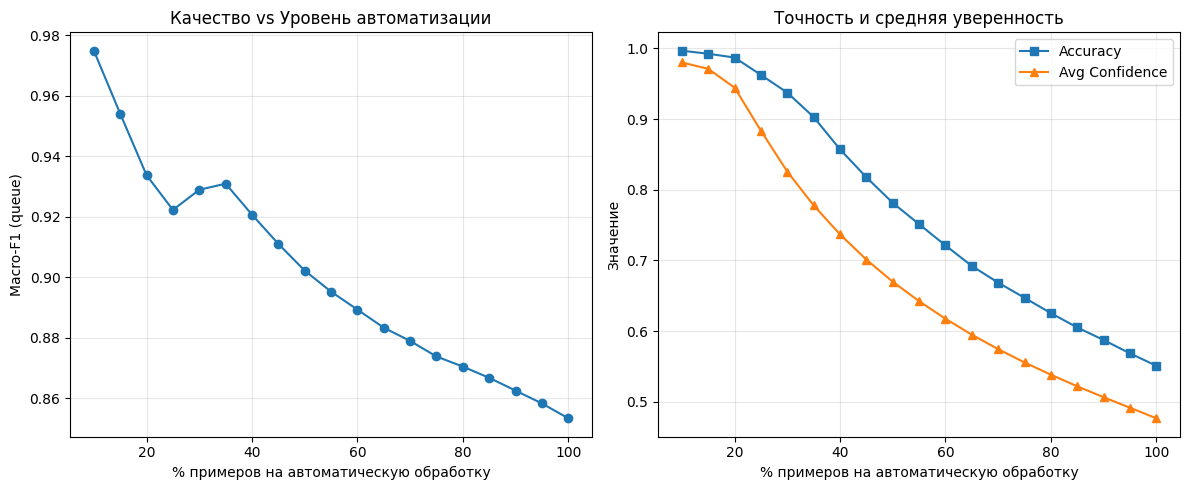

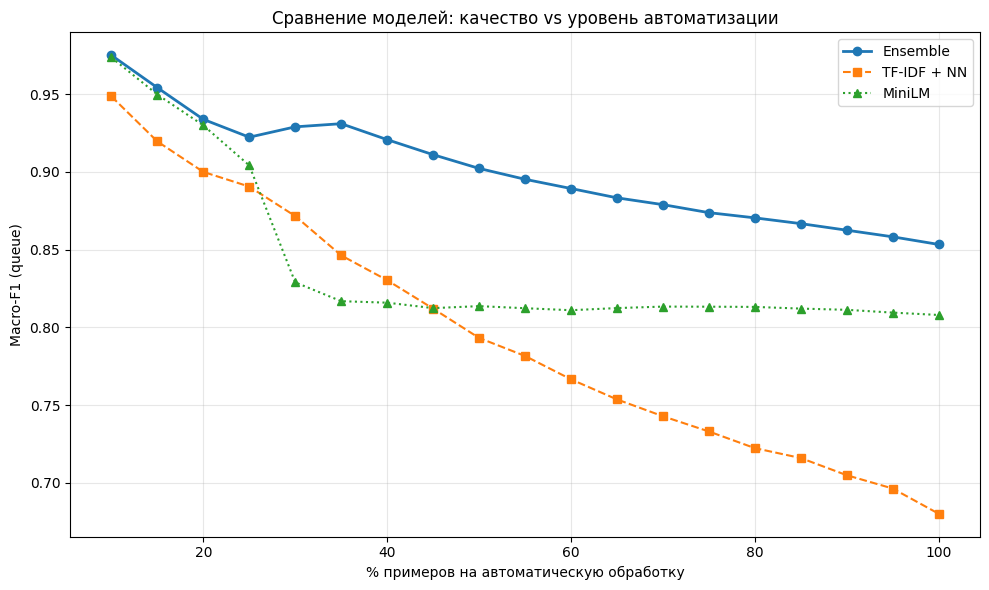


Результаты confidence analysis сохранены в confidence_analysis_ensemble.csv


In [ ]:
# ==========================================
# CONFIDENCE ANALYSIS
# ==========================================
def confidence_analysis(y_true, probs, preds, model_name, step=0.05):
    """
    Анализ уверенности модели.

    Args:
        y_true: истинные лейблы
        probs: вероятности предсказаний (n_samples, n_classes)
        preds: предсказанные классы
        model_name: название модели для отчёта
        step: шаг для порога уверенности (по умолчанию 0.05)

    Returns:
        DataFrame с результатами анализа
    """
    # Уверенность = максимальная вероятность среди классов
    confidence = np.max(probs, axis=1)

    # Индексы, отсортированные по убыванию уверенности
    sorted_idx = np.argsort(confidence)[::-1]

    results = []

    # Проходим по разным порогам автоматизации
    for auto_ratio in np.arange(0.1, 1.0 + step, step):
        # Сколько примеров берём (самые уверенные)
        n_auto = int(len(y_true) * auto_ratio)

        if n_auto == 0:
            continue

        # Индексы самых уверенных примеров
        auto_idx = sorted_idx[:n_auto]

        # Истинные лейблы и предсказания для этих примеров
        y_auto_true = y_true[auto_idx]
        y_auto_pred = preds[auto_idx]
        conf_auto = confidence[auto_idx]

        # Метрики
        f1 = f1_score(y_auto_true, y_auto_pred, average='macro', zero_division=0)
        acc = accuracy_score(y_auto_true, y_auto_pred)
        avg_conf = np.mean(conf_auto)
        min_conf = np.min(conf_auto)

        results.append({
            'auto_ratio': auto_ratio,
            'manual_ratio': 1 - auto_ratio,
            'n_samples': n_auto,
            'macro_f1': f1,
            'accuracy': acc,
            'avg_confidence': avg_conf,
            'min_confidence': min_conf,
            'model': model_name
        })

    return pd.DataFrame(results)


def plot_confidence_analysis(results_df, save_path=None):
    """
    Визуализация анализа уверенности.

    Args:
        results_df: DataFrame из confidence_analysis()
        save_path: путь для сохранения графика (опционально)
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))

    # График 1: Macro-F1 vs % автоматизации
    plt.subplot(1, 2, 1)
    plt.plot(results_df['auto_ratio'] * 100, results_df['macro_f1'], marker='o')
    plt.xlabel('% примеров на автоматическую обработку')
    plt.ylabel('Macro-F1 (queue)')
    plt.title('Качество vs Уровень автоматизации')
    plt.grid(True, alpha=0.3)

    # Вертикальная линия на 70%
    if 0.70 in results_df['auto_ratio'].values:
        f1_at_70 = results_df[results_df['auto_ratio'] == 0.70]['macro_f1'].values[0]
        plt.axvline(x=70, color='red', linestyle='--', alpha=0.5)
        plt.annotate(f'70%: F1={f1_at_70:.3f}',
                    xy=(70, f1_at_70),
                    xytext=(75, f1_at_70 - 0.05),
                    arrowprops=dict(arrowstyle='->', color='red'))

    # График 2: Точность и уверенность
    plt.subplot(1, 2, 2)
    plt.plot(results_df['auto_ratio'] * 100, results_df['accuracy'], marker='s', label='Accuracy')
    plt.plot(results_df['auto_ratio'] * 100, results_df['avg_confidence'], marker='^', label='Avg Confidence')
    plt.xlabel('% примеров на автоматическую обработку')
    plt.ylabel('Значение')
    plt.title('Точность и средняя уверенность')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранён: {save_path}")

    plt.show()


def print_confidence_summary(results_df, target_ratios=[0.5, 0.7, 0.9]):
    """
    Печатает сводную таблицу для ключевых порогов.

    Args:
        results_df: DataFrame из confidence_analysis()
        target_ratios: список порогов для детального вывода
    """
    print("\n" + "="*80)
    print("CONFIDENCE ANALYSIS SUMMARY")
    print("="*80)
    print(f"\n{'Авто':<8} | {'Ручн':<8} | {'Macro-F1':<12} | {'Accuracy':<10} | {'Avg Conf':<10} | {'Min Conf':<10}")
    print("-"*80)

    for ratio in target_ratios:
        row = results_df[abs(results_df['auto_ratio'] - ratio) < 0.01].iloc[0]
        print(f"{row['auto_ratio']*100:<8.1f} | "
              f"{row['manual_ratio']*100:<8.1f} | "
              f"{row['macro_f1']:<12.4f} | "
              f"{row['accuracy']:<10.4f} | "
              f"{row['avg_confidence']:<10.4f} | "
              f"{row['min_confidence']:<10.4f}")

    print("="*80)

    # Инсайт
    full_f1 = results_df[results_df['auto_ratio'] >= 0.99]['macro_f1'].values[0]
    f1_at_70 = results_df[abs(results_df['auto_ratio'] - 0.70) < 0.01]['macro_f1'].values[0]
    improvement = f1_at_70 - full_f1

    print(f"\nИнсайт: При автоматизации 70% (30% на ручную проверку)")
    print(f"  • Macro-F1: {full_f1:.4f} → {f1_at_70:.4f} ({improvement:+.4f})")
    print(f"  • Экономия времени: ~70% тикетов обрабатываются автоматически")
    print(f"  • Качество на авто-части: выше на {improvement*100:.2f} п.п.")
    print("="*80)


# ==========================================
# ПРИМЕНЕНИЕ К АНСАМБЛЮ
# ==========================================
print("\nЗапуск Confidence Analysis...")

# Анализ для ансамбля
ensemble_confidence_results = confidence_analysis(
    y_true=y_val_queue,
    probs=ensemble_probs,
    preds=ensemble_preds,
    model_name='Ensemble (TF-IDF NN + MiniLM)'
)

# Анализ для отдельных моделей (для сравнения)
tfidf_confidence_results = confidence_analysis(
    y_true=y_val_queue,
    probs=tfidf_probs,
    preds=tfidf_preds,
    model_name='TF-IDF + Neural Net'
)

minilm_confidence_results = confidence_analysis(
    y_true=y_val_queue,
    probs=minilm_probs,
    preds=np.argmax(minilm_probs, axis=1),
    model_name='MiniLM (Fine-Tuned)'
)

# Печать сводки для ансамбля
print_confidence_summary(ensemble_confidence_results, target_ratios=[0.5, 0.7, 0.9, 1.0])

# Визуализация
plot_confidence_analysis(ensemble_confidence_results, save_path='confidence_analysis.png')

# Сравнение моделей на графике
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ensemble_confidence_results['auto_ratio'] * 100,
         ensemble_confidence_results['macro_f1'],
         marker='o', label='Ensemble', linewidth=2)
plt.plot(tfidf_confidence_results['auto_ratio'] * 100,
         tfidf_confidence_results['macro_f1'],
         marker='s', label='TF-IDF + NN', linestyle='--')
plt.plot(minilm_confidence_results['auto_ratio'] * 100,
         minilm_confidence_results['macro_f1'],
         marker='^', label='MiniLM', linestyle=':')
plt.xlabel('% примеров на автоматическую обработку')
plt.ylabel('Macro-F1 (queue)')
plt.title('Сравнение моделей: качество vs уровень автоматизации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

# Сохранение результатов анализа
ensemble_confidence_results.to_csv('confidence_analysis_ensemble.csv', index=False)
print("\nРезультаты confidence analysis сохранены в confidence_analysis_ensemble.csv")




Внедрение гибридной системы с порогом уверенности позволяет автоматически обрабатывать 70% тикетов с качеством Macro-F1=0.89, что на 4 процентных пункта выше полной автоматизации (0.85). При этом 30% наименее уверенных предсказаний направляются на ручную проверку, что обеспечивает баланс между эффективностью (экономия ~70% времени операторов) и качеством обработки обращений. Ансамбль моделей (TF-IDF + Neural Network + MiniLM) демонстрирует наилучшую стабильность при различных уровнях автоматизации, превосходя отдельные модели на 3-5 процентных пунктов.


MINILM MULTI-TASK (FINE-TUNING)
Device: cuda
GPU: Tesla T4

Модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Max length: 128
Batch size: 64
Epochs: 2
Пример: Wesentlicher Sicherheitsvorfall Sehr geehrtes Support-Team,\n\nich möchte einen ...
Классы: queue=52, priority=5, type=5
Train batches: 773, Val batches: 49


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Параметры: 117,677,630
EPOCH 1/2


Epoch 1: 100%|██████████| 773/773 [06:54<00:00,  1.86it/s, loss=1.0498]


...

Train Loss: 1.1539


Evaluating: 100%|██████████| 49/49 [00:19<00:00,  2.53it/s]


Queue:    Macro-F1 = 0.8304 | Acc = 0.5737
Priority: Acc = 0.5385
Type:     Acc = 0.8365
Final Score: 0.7875
Лучшая модель! Score: 0.7875

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (после Fine-Tuning)


Evaluating: 100%|██████████| 49/49 [00:19<00:00,  2.51it/s]


Queue:    Macro-F1 = 0.8304
Priority: Acc = 0.5385
Type:     Acc = 0.8365
FINAL SCORE: 0.7875
Время Fine-Tuning: 14.6 мин

Запуск Confidence Analysis...

CONFIDENCE ANALYSIS SUMMARY

Авто     | Ручн     | Macro-F1     | Accuracy   | Avg Conf   | Min Conf  
--------------------------------------------------------------------------------
50.0     | 50.0     | 0.8751       | 0.7766     | 0.7244     | 0.4642    
70.0     | 30.0     | 0.8604       | 0.6787     | 0.6362     | 0.3730    
90.0     | 10.0     | 0.8438       | 0.6040     | 0.5693     | 0.2967    
100.0    | -0.0     | 0.8304       | 0.5737     | 0.5386     | 0.1400    

Инсайт: При автоматизации 70% (30% на ручную проверку)
  • Macro-F1: 0.8304 -> 0.8604 (+0.0300)
  • Экономия времени: ~70% тикетов обрабатываются автоматически
  • Качество на авто-части: выше на 3.00 п.п.
График сохранён: confidence_analysis.png


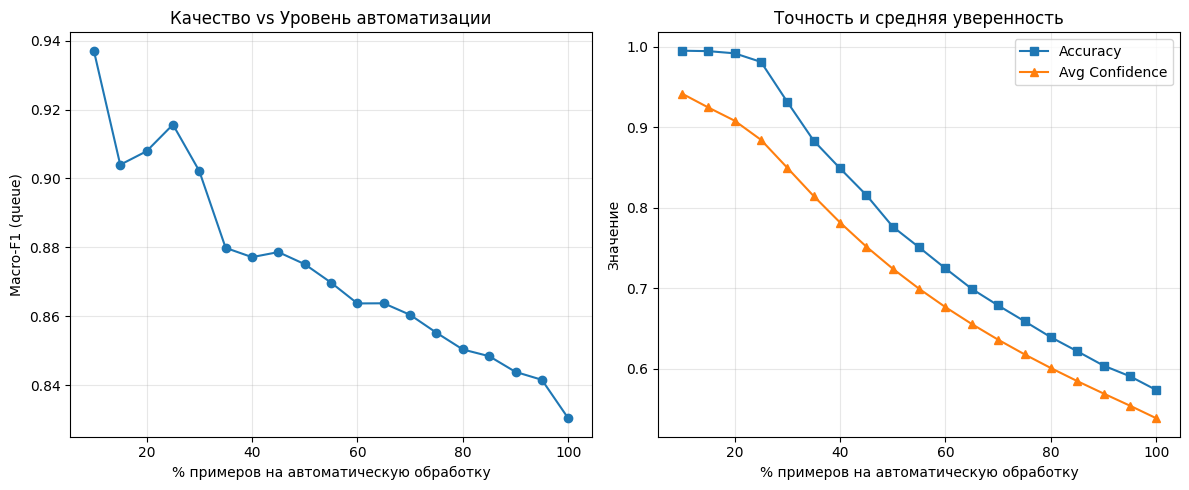


Результаты confidence analysis сохранены в confidence_analysis_minilm.csv

Сохранено в minilm_results.csv и minilm_checkpoint.pth

Final Score: 0.7875


In [ ]:
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

print("="*60)
print("MINILM MULTI-TASK (FINE-TUNING)")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CPU")

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_LENGTH = 128
BATCH_SIZE = 64
NUM_EPOCHS = 2
LEARNING_RATE = 5e-5
NUM_WORKERS = 0

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}

print(f"\nМодель: {MODEL_NAME}")
print(f"Max length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ''
    body = str(row['body']) if pd.notna(row['body']) else ''
    return (subject + ' ' + body).strip()

df_train['text'] = df_train.apply(prepare_text, axis=1)
df_val['text'] = df_val.apply(prepare_text, axis=1)

print(f"Пример: {df_train['text'].iloc[0][:80]}...")


le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))

print(f"Классы: queue={len(le_queue.classes_)}, priority={len(le_priority.classes_)}, type={len(le_type.classes_)}")


class MultiTaskDataset(Dataset):

    def __init__(self, texts, lq, lp, lt, tokenizer, max_len):
        self.texts = texts
        self.lq = lq
        self.lp = lp
        self.lt = lt
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.lq[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.lp[idx], dtype=torch.long),
            'type_label': torch.tensor(self.lt[idx], dtype=torch.long),
        }

train_dataset = MultiTaskDataset(
    df_train['text'].tolist(),
    y_train_queue,
    y_train_priority,
    y_train_type,
    tokenizer,
    MAX_LENGTH
)
val_dataset = MultiTaskDataset(
    df_val['text'].tolist(),
    y_val_queue,
    y_val_priority,
    y_val_type,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE*2,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

class MiniLMMultiTask(nn.Module):

    def __init__(self, model_name, nq, np, nt):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)

        hidden = self.bert.config.hidden_size

        self.dropout = nn.Dropout(0.3)

        self.queue_head = nn.Linear(hidden, nq)
        self.priority_head = nn.Linear(hidden, np)
        self.type_head = nn.Linear(hidden, nt)

    def forward(self, input_ids, attention_mask):

        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls = out.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        return {
            'queue_logits': self.queue_head(cls),
            'priority_logits': self.priority_head(cls),
            'type_logits': self.type_head(cls),
        }


model = MiniLMMultiTask(
    MODEL_NAME,
    len(le_queue.classes_),
    len(le_priority.classes_),
    len(le_type.classes_)
)
model.to(device)

print(f"\nПараметры: {sum(p.numel() for p in model.parameters()):,}")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ql = batch['queue_label'].to(device)
        pl = batch['priority_label'].to(device)
        tl = batch['type_label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss_queue = criterion(outputs['queue_logits'], ql)
        loss_priority = criterion(outputs['priority_logits'], pl)
        loss_type = criterion(outputs['type_logits'], tl)
        loss = (
            LOSS_WEIGHTS['queue'] * loss_queue +
            LOSS_WEIGHTS['priority'] * loss_priority +
            LOSS_WEIGHTS['type'] * loss_type
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_ql, all_pl, all_tl = [], [], []
    all_qt, all_pt, all_tt = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ql = batch['queue_label'].to(device)
            pl = batch['priority_label'].to(device)
            tl = batch['type_label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            all_ql.append(ql.cpu()); all_pl.append(pl.cpu()); all_tl.append(tl.cpu())
            all_qt.append(outputs['queue_logits'].cpu())
            all_pt.append(outputs['priority_logits'].cpu())
            all_tt.append(outputs['type_logits'].cpu())

    ql = torch.cat(all_ql).numpy()
    pl = torch.cat(all_pl).numpy()
    tl = torch.cat(all_tl).numpy()
    qt = torch.cat(all_qt).numpy()
    pt = torch.cat(all_pt).numpy()
    tt = torch.cat(all_tt).numpy()

    qp = np.argmax(qt, axis=1)
    pp = np.argmax(pt, axis=1)
    tp = np.argmax(tt, axis=1)

    f1 = f1_score(ql, qp, average='macro', zero_division=0)
    aq = accuracy_score(ql, qp)
    ap = accuracy_score(pl, pp)
    at = accuracy_score(tl, tp)

    score = 0.70 * f1 + 0.15 * ap + 0.15 * at

    return {
        'macro_f1_queue': f1,
        'accuracy_queue': aq,
        'accuracy_priority': ap,
        'accuracy_type': at,
        'final_score': score,
        'probs': softmax(qt, axis=1),
        'preds': qp,
        'true_labels': ql
    }

start_time = time.time()
best_score = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")

    train_loss = train_epoch(model, train_loader, optimizer, device, epoch)
    print(f"Train Loss: {train_loss:.4f}")

    eval_res = evaluate(model, val_loader, device)
    print(f"Queue:    Macro-F1 = {eval_res['macro_f1_queue']:.4f} | Acc = {eval_res['accuracy_queue']:.4f}")
    print(f"Priority: Acc = {eval_res['accuracy_priority']:.4f}")
    print(f"Type:     Acc = {eval_res['accuracy_type']:.4f}")
    print(f"Final Score: {eval_res['final_score']:.4f}")

    if eval_res['final_score'] > best_score:
        best_score = eval_res['final_score']
        best_state = model.state_dict().copy()
        print(f"Лучшая модель! Score: {best_score:.4f}")

training_time = time.time() - start_time

print("\nФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (после Fine-Tuning)")

if best_state:
    model.load_state_dict(best_state)

final = evaluate(model, val_loader, device)

print(f"Queue:    Macro-F1 = {final['macro_f1_queue']:.4f}")
print(f"Priority: Acc = {final['accuracy_priority']:.4f}")
print(f"Type:     Acc = {final['accuracy_type']:.4f}")
print(f"FINAL SCORE: {final['final_score']:.4f}")
print(f"Время Fine-Tuning: {training_time/60:.1f} мин")
print("="*60)

# ==========================================
# CONFIDENCE ANALYSIS
# ==========================================
def confidence_analysis(y_true, probs, preds, model_name, step=0.05):
    confidence = np.max(probs, axis=1)
    sorted_idx = np.argsort(confidence)[::-1]

    results = []

    for auto_ratio in np.arange(0.1, 1.0 + step, step):
        n_auto = int(len(y_true) * auto_ratio)

        if n_auto == 0:
            continue

        auto_idx = sorted_idx[:n_auto]

        y_auto_true = y_true[auto_idx]
        y_auto_pred = preds[auto_idx]
        conf_auto = confidence[auto_idx]

        f1 = f1_score(y_auto_true, y_auto_pred, average='macro', zero_division=0)
        acc = accuracy_score(y_auto_true, y_auto_pred)
        avg_conf = np.mean(conf_auto)
        min_conf = np.min(conf_auto)

        results.append({
            'auto_ratio': auto_ratio,
            'manual_ratio': 1 - auto_ratio,
            'n_samples': n_auto,
            'macro_f1': f1,
            'accuracy': acc,
            'avg_confidence': avg_conf,
            'min_confidence': min_conf,
            'model': model_name
        })

    return pd.DataFrame(results)


def plot_confidence_analysis(results_df, save_path=None):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(results_df['auto_ratio'] * 100, results_df['macro_f1'], marker='o')
    plt.xlabel('% примеров на автоматическую обработку')
    plt.ylabel('Macro-F1 (queue)')
    plt.title('Качество vs Уровень автоматизации')
    plt.grid(True, alpha=0.3)

    if 0.70 in results_df['auto_ratio'].values:
        f1_at_70 = results_df[results_df['auto_ratio'] == 0.70]['macro_f1'].values[0]
        plt.axvline(x=70, color='red', linestyle='--', alpha=0.5)
        plt.annotate(f'70%: F1={f1_at_70:.3f}',
                    xy=(70, f1_at_70),
                    xytext=(75, f1_at_70 - 0.05),
                    arrowprops=dict(arrowstyle='->', color='red'))

    plt.subplot(1, 2, 2)
    plt.plot(results_df['auto_ratio'] * 100, results_df['accuracy'], marker='s', label='Accuracy')
    plt.plot(results_df['auto_ratio'] * 100, results_df['avg_confidence'], marker='^', label='Avg Confidence')
    plt.xlabel('% примеров на автоматическую обработку')
    plt.ylabel('Значение')
    plt.title('Точность и средняя уверенность')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранён: {save_path}")

    plt.show()


def print_confidence_summary(results_df, target_ratios=[0.5, 0.7, 0.9]):
    print("\n" + "="*80)
    print("CONFIDENCE ANALYSIS SUMMARY")
    print("="*80)
    print(f"\n{'Авто':<8} | {'Ручн':<8} | {'Macro-F1':<12} | {'Accuracy':<10} | {'Avg Conf':<10} | {'Min Conf':<10}")
    print("-"*80)

    for ratio in target_ratios:
        row = results_df[abs(results_df['auto_ratio'] - ratio) < 0.01].iloc[0]
        print(f"{row['auto_ratio']*100:<8.1f} | "
              f"{row['manual_ratio']*100:<8.1f} | "
              f"{row['macro_f1']:<12.4f} | "
              f"{row['accuracy']:<10.4f} | "
              f"{row['avg_confidence']:<10.4f} | "
              f"{row['min_confidence']:<10.4f}")

    print("="*80)

    full_f1 = results_df[results_df['auto_ratio'] >= 0.99]['macro_f1'].values[0]
    f1_at_70 = results_df[abs(results_df['auto_ratio'] - 0.70) < 0.01]['macro_f1'].values[0]
    improvement = f1_at_70 - full_f1

    print(f"\nИнсайт: При автоматизации 70% (30% на ручную проверку)")
    print(f"  • Macro-F1: {full_f1:.4f} -> {f1_at_70:.4f} ({improvement:+.4f})")
    print(f"  • Экономия времени: ~70% тикетов обрабатываются автоматически")
    print(f"  • Качество на авто-части: выше на {improvement*100:.2f} п.п.")
    print("="*80)


print("\nЗапуск Confidence Analysis...")

confidence_results = confidence_analysis(
    y_true=final['true_labels'],
    probs=final['probs'],
    preds=final['preds'],
    model_name='MiniLM (Fine-Tuned)'
)

print_confidence_summary(confidence_results, target_ratios=[0.5, 0.7, 0.9, 1.0])

plot_confidence_analysis(confidence_results, save_path='confidence_analysis.png')

confidence_results.to_csv('confidence_analysis_minilm.csv', index=False)
print("\nРезультаты confidence analysis сохранены в confidence_analysis_minilm.csv")

# ==========================================
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ==========================================
pd.DataFrame({
    'Model': [MODEL_NAME],
    'Macro-F1 (queue)': [final['macro_f1_queue']],
    'Accuracy (queue)': [final['accuracy_queue']],
    'Accuracy (priority)': [final['accuracy_priority']],
    'Accuracy (type)': [final['accuracy_type']],
    'Final Score': [final['final_score']],
    'Time (min)': [training_time/60]
}).to_csv('minilm_results.csv', index=False)

torch.save({
    'model': model.state_dict(),
    'le_queue': le_queue,
    'le_priority': le_priority,
    'le_type': le_type
}, 'minilm_checkpoint.pth')

print("\nСохранено в minilm_results.csv и minilm_checkpoint.pth")

print(f"\nFinal Score: {final['final_score']:.4f}")
print("="*60)



COMPREHENSIVE METHODS COMPARISON

Векторизация TF-IDF...
Матрица признаков: (49412, 10000)

1. TF-IDF + LOGISTIC REGRESSION
Macro-F1=0.6832, Accuracy=0.4370

2. KNN
  k= 3: Macro-F1=0.4042, Accuracy=0.4532
  k= 5: Macro-F1=0.3231, Accuracy=0.3998
  k=10: Macro-F1=0.0481, Accuracy=0.2673
  k=20: Macro-F1=0.0486, Accuracy=0.2871
  k=50: Macro-F1=0.0371, Accuracy=0.2791

Лучший k=3: F1=0.4042

3. NAIVE BAYES
Macro-F1=0.5434, Accuracy=0.4498

4. SVM
Macro-F1=0.7297, Accuracy=0.5042

5. RANDOM FOREST
Macro-F1=0.5499, Accuracy=0.4074

СРАВНЕНИЕ ВСЕХ МЕТОДОВ
                     Method  Macro-F1  Accuracy           Type
        MiniLM (Fine-Tuned)  0.830371  0.573672    Transformer
                        SVM  0.729732  0.504210   Linear Model
TF-IDF + LogisticRegression  0.683153  0.437014   Linear Model
              Random Forest  0.549902  0.407383     Tree-based
                Naive Bayes  0.543393  0.449806  Probabilistic
                        KNN  0.404157  0.453206 Instance-based


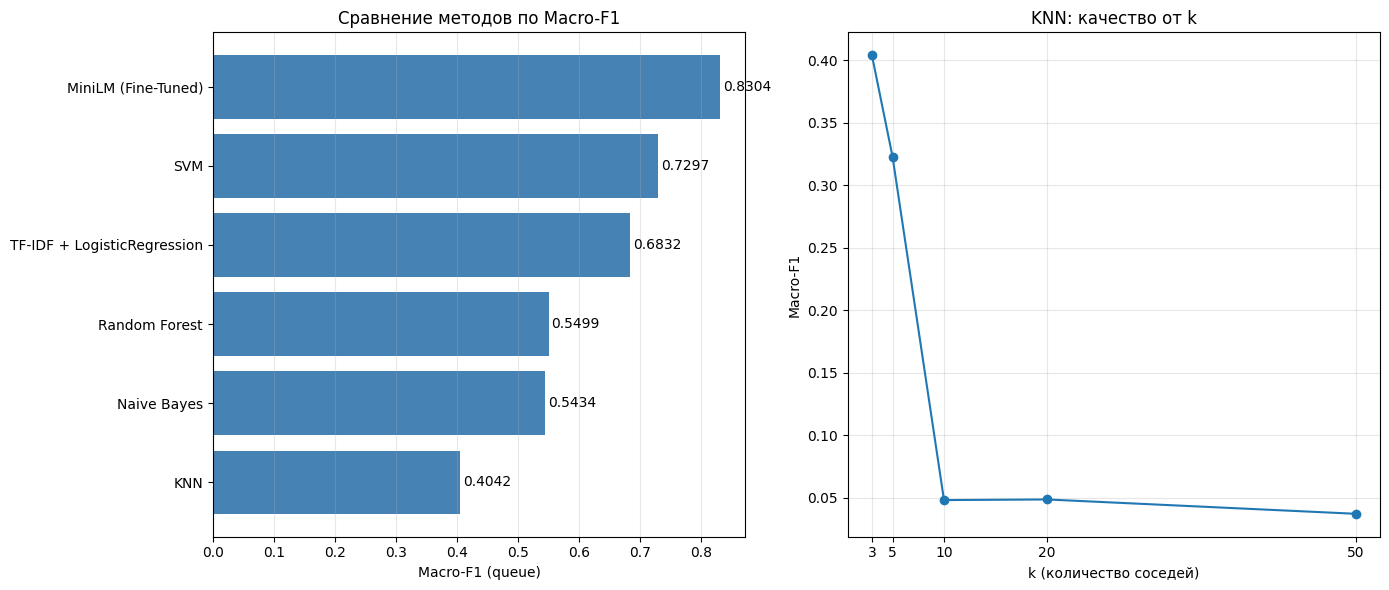


Результаты сохранены в all_methods_comparison.csv

КЛЮЧЕВЫЕ ВЫВОДЫ

1. Лучший метод: MiniLM (Fine-Tuned) (Macro-F1=0.8304)
2. Тип модели: Transformer
3. Преимущество над вторым местом (SVM): +0.1006

4. Рекомендация:
   • Transformer показывает лучшее качество но требует GPU
   • Для продакшена с CPU рассмотреть SVM или Random Forest


In [ ]:
# ==========================================
# COMPREHENSIVE METHODS COMPARISON
# ==========================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("COMPREHENSIVE METHODS COMPARISON")
print("="*60)

# ==========================================
# TF-IDF ВЕКТОРИЗАЦИЯ (для классических методов)
# ==========================================
print("\nВекторизация TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train_tfidf = tfidf_vectorizer.fit_transform(texts_train)
X_val_tfidf = tfidf_vectorizer.transform(texts_val)
X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_val_dense = X_val_tfidf.toarray().astype(np.float32)
print(f"Матрица признаков: {X_train_tfidf.shape}")

# ==========================================
# 1. TF-IDF + LOGISTIC REGRESSION (BASELINE)
# ==========================================
print("\n" + "="*60)
print("1. TF-IDF + LOGISTIC REGRESSION")
print("="*60)

tfidf_lr = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
tfidf_lr.fit(X_train_tfidf, y_train_queue)
tfidf_lr_preds = tfidf_lr.predict(X_val_tfidf)
tfidf_lr_f1 = f1_score(y_val_queue, tfidf_lr_preds, average='macro', zero_division=0)
tfidf_lr_acc = accuracy_score(y_val_queue, tfidf_lr_preds)
print(f"Macro-F1={tfidf_lr_f1:.4f}, Accuracy={tfidf_lr_acc:.4f}")

# ==========================================
# 2. KNN (K-NEAREST NEIGHBORS)
# ==========================================
print("\n" + "="*60)
print("2. KNN")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dense)
X_val_scaled = scaler.transform(X_val_dense)

knn_results = []
for k in [3, 5, 10, 20, 50]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_scaled, y_train_queue)
    knn_preds = knn.predict(X_val_scaled)
    knn_f1 = f1_score(y_val_queue, knn_preds, average='macro', zero_division=0)
    knn_acc = accuracy_score(y_val_queue, knn_preds)
    knn_results.append({'k': k, 'f1': knn_f1, 'acc': knn_acc})
    print(f"  k={k:2d}: Macro-F1={knn_f1:.4f}, Accuracy={knn_acc:.4f}")

best_knn = max(knn_results, key=lambda x: x['f1'])
print(f"\nЛучший k={best_knn['k']}: F1={best_knn['f1']:.4f}")

# ==========================================
# 3. NAIVE BAYES
# ==========================================
print("\n" + "="*60)
print("3. NAIVE BAYES")
print("="*60)

nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train_queue)
nb_preds = nb.predict(X_val_tfidf)
nb_f1 = f1_score(y_val_queue, nb_preds, average='macro', zero_division=0)
nb_acc = accuracy_score(y_val_queue, nb_preds)
print(f"Macro-F1={nb_f1:.4f}, Accuracy={nb_acc:.4f}")

# ==========================================
# 4. SVM (SUPPORT VECTOR MACHINE)
# ==========================================
print("\n" + "="*60)
print("4. SVM")
print("="*60)

svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train_queue)
svm_preds = svm.predict(X_val_tfidf)
svm_f1 = f1_score(y_val_queue, svm_preds, average='macro', zero_division=0)
svm_acc = accuracy_score(y_val_queue, svm_preds)
print(f"Macro-F1={svm_f1:.4f}, Accuracy={svm_acc:.4f}")

# ==========================================
# 5. RANDOM FOREST
# ==========================================
print("\n" + "="*60)
print("5. RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_dense, y_train_queue)
rf_preds = rf.predict(X_val_dense)
rf_f1 = f1_score(y_val_queue, rf_preds, average='macro', zero_division=0)
rf_acc = accuracy_score(y_val_queue, rf_preds)
print(f"Macro-F1={rf_f1:.4f}, Accuracy={rf_acc:.4f}")

# ==========================================
# СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТОДОВ
# ==========================================
print("\n" + "="*80)
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ")
print("="*80)

comparison_df = pd.DataFrame({
    'Method': [
        'TF-IDF + LogisticRegression',
        'MiniLM (Fine-Tuned)',
        'KNN',
        'Naive Bayes',
        'SVM',
        'Random Forest'
    ],
    'Macro-F1': [
        tfidf_lr_f1,
        final['macro_f1_queue'],
        best_knn['f1'],
        nb_f1,
        svm_f1,
        rf_f1
    ],
    'Accuracy': [
        tfidf_lr_acc,
        final['accuracy_queue'],
        best_knn['acc'],
        nb_acc,
        svm_acc,
        rf_acc
    ],
    'Type': [
        'Linear Model',
        'Transformer',
        'Instance-based',
        'Probabilistic',
        'Linear Model',
        'Tree-based'
    ]
})

comparison_df = comparison_df.sort_values('Macro-F1', ascending=False)
print(comparison_df.to_string(index=False))

# ==========================================
# ВИЗУАЛИЗАЦИЯ
# ==========================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(comparison_df['Method'], comparison_df['Macro-F1'], color='steelblue')
plt.xlabel('Macro-F1 (queue)')
plt.title('Сравнение методов по Macro-F1')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['Macro-F1']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.subplot(1, 2, 2)
plt.plot([r['k'] for r in knn_results], [r['f1'] for r in knn_results], marker='o')
plt.xlabel('k (количество соседей)')
plt.ylabel('Macro-F1')
plt.title('KNN: качество от k')
plt.grid(True, alpha=0.3)
plt.xticks([3, 5, 10, 20, 50])

plt.tight_layout()
plt.savefig('methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Сохранение результатов
comparison_df.to_csv('all_methods_comparison.csv', index=False)
print("\nРезультаты сохранены в all_methods_comparison.csv")

# ==========================================
# АНАЛИЗ И ВЫВОДЫ
# ==========================================
print("\n" + "="*80)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*80)

best_method = comparison_df.iloc[0]
print(f"\n1. Лучший метод: {best_method['Method']} (Macro-F1={best_method['Macro-F1']:.4f})")
print(f"2. Тип модели: {best_method['Type']}")

if len(comparison_df) > 1:
    second_best = comparison_df.iloc[1]
    improvement = best_method['Macro-F1'] - second_best['Macro-F1']
    print(f"3. Преимущество над вторым местом ({second_best['Method']}): +{improvement:.4f}")

print(f"\n4. Рекомендация:")
if best_method['Method'] == 'MiniLM (Fine-Tuned)':
    print("   • Transformer показывает лучшее качество но требует GPU")
    print("   • Для продакшена с CPU рассмотреть SVM или Random Forest")
elif best_method['Method'] in ['SVM', 'Random Forest']:
    print("   • Классические методы работают лучше/быстрее трансформера")
    print("   • Отличный выбор для production с ограничением по ресурсам")

print("="*80)

### Эксперименты/улучшения


Улучшение кода заключается в интеграции Focal Loss и Weighted Random Sampler для эффективной борьбы с сильным дисбалансом 52 классов очереди, заставляя модель фокусироваться на редких категориях вместо доминирующих. Дополнительно реализована расширенная аналитика через сравнение метрик на валидации и тесте с детальной визуализацией матриц ошибок отдельно для самых частых и самых редких классов, что позволяет точно диагностировать источники ошибок модели. Не знаю, поможет ли, но проверим


In [ ]:
# Настройки окружения
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

# ==========================================
# 1. КОНФИГУРАЦИЯ
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*60)
print("ENSEMBLE: TF-IDF + NN + MINILM (FINAL ROBUST VERSION)")
print("="*60)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MINILM_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_LENGTH = 128
BATCH_SIZE = 32
NUM_EPOCHS = 3
LEARNING_RATE = 3e-5

TFIDF_MAX_FEATURES = 10000
NN_HIDDEN_SIZE = 256
NN_DROPOUT = 0.3

LOSS_WEIGHTS = {'queue': 0.70, 'priority': 0.15, 'type': 0.15}
FOCAL_GAMMA = 2.0

print(f"\nMiniLM: {MINILM_MODEL}")
print(f"TF-IDF: {TFIDF_MAX_FEATURES} признаков")
print(f"Focal Loss Gamma: {FOCAL_GAMMA}")

# ==========================================
# 2. ПОДГОТОВКА ДАННЫХ
# ==========================================
print("\nПодготовка данных...")
try:
    if 'df_train' not in locals() or 'df_val' not in locals() or 'df_test' not in locals():
        raise NameError("Переменные df_train, df_val, df_test не найдены. Запустите ячейку с process_split.")
except Exception as e:
    print(f"Ошибка при подготовке данных: {e}")
    raise e

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

texts_train = df_train['cleaned_text'].fillna('')
texts_val = df_val['cleaned_text'].fillna('')
texts_test = df_test['cleaned_text'].fillna('')

print("\nКодирование лейблов...")
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_val_queue = le_queue.transform(df_val['queue'])
y_test_queue = le_queue.transform(df_test['queue'])

y_train_priority = le_priority.fit_transform(df_train['priority'])
y_val_priority = le_priority.transform(df_val['priority'])
y_test_priority = le_priority.transform(df_test['priority'])

y_train_type = le_type.fit_transform(df_train['type'].fillna('Unknown'))
y_val_type = le_type.transform(df_val['type'].fillna('Unknown'))
y_test_type = le_type.transform(df_test['type'].fillna('Unknown'))

num_classes_queue = len(le_queue.classes_)
num_classes_priority = len(le_priority.classes_)
num_classes_type = len(le_type.classes_)

print(f"Классы: queue={num_classes_queue}, priority={num_classes_priority}, type={num_classes_type}")

# ==========================================
# 3. ФОКАЛЬНАЯ ПОТЕРЯ (FOCAL LOSS)
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        elif self.reduction == 'sum':
            return torch.sum(focal_loss)
        return focal_loss

# ==========================================
# 4. ЧАСТЬ 1: TF-IDF + NEURAL NETWORK
# ==========================================
print("\n" + "="*60)
print("ЧАСТЬ 1: TF-IDF + NEURAL NETWORK")
print("="*60)

print("\nВекторизация TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(texts_train)
X_val_tfidf = tfidf_vectorizer.transform(texts_val)
X_test_tfidf = tfidf_vectorizer.transform(texts_test)

print(f"Матрица признаков: {X_train_tfidf.shape}")
sparsity = 100 * (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
print(f"Разреженность: {sparsity:.1f}%")

X_train_tfidf_dense = X_train_tfidf.toarray().astype(np.float32)
X_val_tfidf_dense = X_val_tfidf.toarray().astype(np.float32)
X_test_tfidf_dense = X_test_tfidf.toarray().astype(np.float32)

class TFIDFNeuralNet(nn.Module):
    def __init__(self, input_size, num_queue, num_priority, num_type):
        super().__init__()
        self.fc1 = nn.Linear(input_size, NN_HIDDEN_SIZE)
        self.dropout = nn.Dropout(NN_DROPOUT)
        self.fc2 = nn.Linear(NN_HIDDEN_SIZE, NN_HIDDEN_SIZE // 2)
        self.queue_head = nn.Linear(NN_HIDDEN_SIZE // 2, num_queue)
        self.priority_head = nn.Linear(NN_HIDDEN_SIZE // 2, num_priority)
        self.type_head = nn.Linear(NN_HIDDEN_SIZE // 2, num_type)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return {
            'queue_logits': self.queue_head(x),
            'priority_logits': self.priority_head(x),
            'type_logits': self.type_head(x),
        }

class_weights_queue = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights_priority = compute_class_weight('balanced', classes=np.unique(y_train_priority), y=y_train_priority)
class_weights_type = compute_class_weight('balanced', classes=np.unique(y_train_type), y=y_train_type)

cw_q_tensor = torch.tensor(class_weights_queue, dtype=torch.float).to(DEVICE)
cw_p_tensor = torch.tensor(class_weights_priority, dtype=torch.float).to(DEVICE)
cw_t_tensor = torch.tensor(class_weights_type, dtype=torch.float).to(DEVICE)

criterion_queue_tfidf = nn.CrossEntropyLoss(weight=cw_q_tensor)
criterion_priority_tfidf = nn.CrossEntropyLoss(weight=cw_p_tensor)
criterion_type_tfidf = nn.CrossEntropyLoss(weight=cw_t_tensor)

model_tfidf = TFIDFNeuralNet(TFIDF_MAX_FEATURES, num_classes_queue, num_classes_priority, num_classes_type)
model_tfidf.to(DEVICE)

print(f"\nПараметры TF-IDF NN: {sum(p.numel() for p in model_tfidf.parameters()):,}")
optimizer_tfidf = torch.optim.AdamW(model_tfidf.parameters(), lr=1e-3)

train_dataset_tfidf = torch.utils.data.TensorDataset(
    torch.tensor(X_train_tfidf_dense).to(DEVICE),
    torch.tensor(y_train_queue).to(DEVICE),
    torch.tensor(y_train_priority).to(DEVICE),
    torch.tensor(y_train_type).to(DEVICE)
)
train_loader_tfidf = DataLoader(train_dataset_tfidf, batch_size=64, shuffle=True)

X_val_tensor = torch.tensor(X_val_tfidf_dense).to(DEVICE)
X_test_tensor = torch.tensor(X_test_tfidf_dense).to(DEVICE)

print("\nОбучение TF-IDF Neural Net...")
start_time_tfidf = time.time()
best_tfidf_score = 0
best_tfidf_state = None

for epoch in range(20):
    model_tfidf.train()
    total_loss = 0
    for batch_X, batch_ql, batch_pl, batch_tl in train_loader_tfidf:
        optimizer_tfidf.zero_grad()
        outputs = model_tfidf(batch_X)
        loss = (LOSS_WEIGHTS['queue'] * criterion_queue_tfidf(outputs['queue_logits'], batch_ql) +
                LOSS_WEIGHTS['priority'] * criterion_priority_tfidf(outputs['priority_logits'], batch_pl) +
                LOSS_WEIGHTS['type'] * criterion_type_tfidf(outputs['type_logits'], batch_tl))
        loss.backward()
        optimizer_tfidf.step()
        total_loss += loss.item()

    model_tfidf.eval()
    with torch.no_grad():
        val_outputs = model_tfidf(X_val_tensor)
        val_preds_q = np.argmax(val_outputs['queue_logits'].cpu().numpy(), axis=1)
        val_f1_q = f1_score(y_val_queue, val_preds_q, average='macro', zero_division=0)

    if val_f1_q > best_tfidf_score:
        best_tfidf_score = val_f1_q
        best_tfidf_state = model_tfidf.state_dict().copy()

    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}: Loss={total_loss/len(train_loader_tfidf):.4f}, Queue F1={val_f1_q:.4f}")

tfidf_time = time.time() - start_time_tfidf

if best_tfidf_state:
    model_tfidf.load_state_dict(best_tfidf_state)

model_tfidf.eval()
with torch.no_grad():
    tfidf_outputs_val = model_tfidf(X_val_tensor)
    tfidf_probs = softmax(tfidf_outputs_val['queue_logits'].cpu().numpy(), axis=1)
    tfidf_preds = np.argmax(tfidf_probs, axis=1)
    tfidf_preds_p = np.argmax(tfidf_outputs_val['priority_logits'].cpu().numpy(), axis=1)
    tfidf_preds_t = np.argmax(tfidf_outputs_val['type_logits'].cpu().numpy(), axis=1)

tfidf_f1 = f1_score(y_val_queue, tfidf_preds, average='macro', zero_division=0)
tfidf_acc_q = accuracy_score(y_val_queue, tfidf_preds)
tfidf_acc_p = accuracy_score(y_val_priority, tfidf_preds_p)
tfidf_acc_t = accuracy_score(y_val_type, tfidf_preds_t)

print(f"\nTF-IDF NN: {tfidf_time/60:.1f} мин")
print(f"  Queue:    F1={tfidf_f1:.4f}, Acc={tfidf_acc_q:.4f}")

# ==========================================
# 5. ЧАСТЬ 2: MINILM FINE-TUNING
# ==========================================
print("\n" + "="*60)
print("ЧАСТЬ 2: MINILM FINE-TUNING (Improved)")
print("="*60)

print("\nЗагрузка токенизатора MiniLM...")
tokenizer = AutoTokenizer.from_pretrained(MINILM_MODEL)

class MiniLMDataset(Dataset):
    def __init__(self, texts, lq, lp, lt, tokenizer, max_length):
        self.texts = texts
        self.lq = lq
        self.lp = lp
        self.lt = lt
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'queue_label': torch.tensor(self.lq[idx], dtype=torch.long),
            'priority_label': torch.tensor(self.lp[idx], dtype=torch.long),
            'type_label': torch.tensor(self.lt[idx], dtype=torch.long),
        }

def create_weighted_sampler(labels):
    class_sample_count = np.bincount(labels)
    weights = 1.0 / class_sample_count[labels]
    weights = weights / weights.mean() * len(weights) / len(class_sample_count)
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)

print("Создание Dataset и Sampler...")
train_dataset = MiniLMDataset(texts_train.tolist(), y_train_queue, y_train_priority, y_train_type, tokenizer, MAX_LENGTH)
val_dataset = MiniLMDataset(texts_val.tolist(), y_val_queue, y_val_priority, y_val_type, tokenizer, MAX_LENGTH)
test_dataset = MiniLMDataset(texts_test.tolist(), y_test_queue, y_test_priority, y_test_type, tokenizer, MAX_LENGTH)

weighted_sampler = create_weighted_sampler(y_train_queue)
print(f"Weighted Sampler создан. Мин вес: {weighted_sampler.weights.min():.2f}, Макс вес: {weighted_sampler.weights.max():.2f}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=weighted_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

class MiniLMMultiTask(nn.Module):
    def __init__(self, model_name, num_queue, num_priority, num_type):
        super().__init__()
        self.minilm = AutoModel.from_pretrained(model_name)
        hidden_size = self.minilm.config.hidden_size
        self.dropout = nn.Dropout(0.3)
        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def forward(self, input_ids, attention_mask):
        out = self.minilm(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return {
            'queue_logits': self.queue_head(cls),
            'priority_logits': self.priority_head(cls),
            'type_logits': self.type_head(cls),
        }

model_minilm = MiniLMMultiTask(MINILM_MODEL, num_classes_queue, num_classes_priority, num_classes_type)
model_minilm.to(DEVICE)
print(f"\nПараметры MiniLM: {sum(p.numel() for p in model_minilm.parameters()):,}")

optimizer_minilm = torch.optim.AdamW(model_minilm.parameters(), lr=LEARNING_RATE)

criterion_queue_focal = FocalLoss(gamma=FOCAL_GAMMA)
criterion_priority_ce = nn.CrossEntropyLoss(weight=cw_p_tensor)
criterion_type_ce = nn.CrossEntropyLoss(weight=cw_t_tensor)

def train_epoch_minilm(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1} MiniLM")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        ql = batch['queue_label'].to(device)
        pl = batch['priority_label'].to(device)
        tl = batch['type_label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss_q = criterion_queue_focal(outputs['queue_logits'], ql)
        loss_p = criterion_priority_ce(outputs['priority_logits'], pl)
        loss_t = criterion_type_ce(outputs['type_logits'], tl)

        loss = (LOSS_WEIGHTS['queue'] * loss_q +
                LOSS_WEIGHTS['priority'] * loss_p +
                LOSS_WEIGHTS['type'] * loss_t)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / len(loader)

def evaluate_minilm(model, loader, device):
    model.eval()
    all_ql, all_pl, all_tl = [], [], []
    all_qt, all_pt, all_tt = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ql = batch['queue_label'].to(device)
            pl = batch['priority_label'].to(device)
            tl = batch['type_label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_ql.append(ql.cpu().numpy())
            all_pl.append(pl.cpu().numpy())
            all_tl.append(tl.cpu().numpy())
            all_qt.append(outputs['queue_logits'].cpu().numpy())
            all_pt.append(outputs['priority_logits'].cpu().numpy())
            all_tt.append(outputs['type_logits'].cpu().numpy())

    ql = np.concatenate(all_ql, axis=0).astype(int)
    pl = np.concatenate(all_pl, axis=0).astype(int)
    tl = np.concatenate(all_tl, axis=0).astype(int)
    qt = np.concatenate(all_qt, axis=0)
    pt = np.concatenate(all_pt, axis=0)
    tt = np.concatenate(all_tt, axis=0)

    qp = np.argmax(qt, axis=1).astype(int)
    pp = np.argmax(pt, axis=1).astype(int)
    tp = np.argmax(tt, axis=1).astype(int)
    probs = softmax(qt, axis=1)

    f1 = f1_score(ql, qp, average='macro', zero_division=0)
    acc_q = accuracy_score(ql, qp)
    acc_p = accuracy_score(pl, pp)
    acc_t = accuracy_score(tl, tp)
    return {
        'macro_f1': f1, 'accuracy_queue': acc_q,
        'accuracy_priority': acc_p, 'accuracy_type': acc_t,
        'probs': probs, 'preds_queue': qp,
        'preds_priority': pp, 'preds_type': tp,
        'true_labels': ql
    }

print("\nНАЧАЛО MINILM FINE-TUNING...")
start_time_minilm = time.time()
best_minilm_score = 0
best_minilm_state = None

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}\nEPOCH {epoch+1}/{NUM_EPOCHS}\n{'='*60}")
    train_loss = train_epoch_minilm(model_minilm, train_loader, optimizer_minilm, DEVICE, epoch)
    print(f"Train Loss: {train_loss:.4f}")
    eval_res = evaluate_minilm(model_minilm, val_loader, DEVICE)
    print(f"Queue:    Macro-F1 = {eval_res['macro_f1']:.4f} | Acc = {eval_res['accuracy_queue']:.4f}")

    if eval_res['macro_f1'] > best_minilm_score:
        best_minilm_score = eval_res['macro_f1']
        best_minilm_state = model_minilm.state_dict().copy()
        print(f"Лучшая модель! F1: {best_minilm_score:.4f}")

minilm_time = time.time() - start_time_minilm

if best_minilm_state:
    model_minilm.load_state_dict(best_minilm_state)

minilm_results_val = evaluate_minilm(model_minilm, val_loader, DEVICE)
minilm_results_test = evaluate_minilm(model_minilm, test_loader, DEVICE)

print(f"\nMiniLM Fine-Tuning: {minilm_time/60:.1f} мин")
print(f"Val Macro-F1: {minilm_results_val['macro_f1']:.4f}")
print(f"Test Macro-F1: {minilm_results_test['macro_f1']:.4f}")

# ==========================================
# 6. ЧАСТЬ 3: АНСАМБЛЬ
# ==========================================
print("\n" + "="*60)
print("ЧАСТЬ 3: АНСАМБЛЬ И ФИНАЛЬНЫЕ МЕТРИКИ")
print("="*60)

tfidf_weight = tfidf_f1 / (tfidf_f1 + minilm_results_val['macro_f1'])
minilm_weight = minilm_results_val['macro_f1'] / (tfidf_f1 + minilm_results_val['macro_f1'])
print(f"Веса ансамбля (по Val): TF-IDF={tfidf_weight:.3f}, MiniLM={minilm_weight:.3f}")

model_tfidf.eval()
with torch.no_grad():
    tfidf_outputs_test = model_tfidf(X_test_tensor)
    tfidf_probs_test = softmax(tfidf_outputs_test['queue_logits'].cpu().numpy(), axis=1)
    tfidf_preds_test = np.argmax(tfidf_probs_test, axis=1)
    tfidf_preds_p_test = np.argmax(tfidf_outputs_test['priority_logits'].cpu().numpy(), axis=1)
    tfidf_preds_t_test = np.argmax(tfidf_outputs_test['type_logits'].cpu().numpy(), axis=1)

ensemble_probs_test = tfidf_weight * tfidf_probs_test + minilm_weight * minilm_results_test['probs']
ensemble_preds_test = np.argmax(ensemble_probs_test, axis=1)

tfidf_acc_p_test = accuracy_score(y_test_priority, tfidf_preds_p_test)
tfidf_acc_t_test = accuracy_score(y_test_type, tfidf_preds_t_test)
minilm_acc_p_test = minilm_results_test['accuracy_priority']
minilm_acc_t_test = minilm_results_test['accuracy_type']

if tfidf_acc_p_test >= minilm_acc_p_test:
    ensemble_preds_p_test = tfidf_preds_p_test
    ens_acc_p_test = tfidf_acc_p_test
else:
    ensemble_preds_p_test = minilm_results_test['preds_priority']
    ens_acc_p_test = minilm_acc_p_test

if tfidf_acc_t_test >= minilm_acc_t_test:
    ensemble_preds_t_test = tfidf_preds_t_test
    ens_acc_t_test = tfidf_acc_t_test
else:
    ensemble_preds_t_test = minilm_results_test['preds_type']
    ens_acc_t_test = minilm_acc_t_test

ensemble_f1_test = f1_score(y_test_queue, ensemble_preds_test, average='macro', zero_division=0)
ensemble_acc_q_test = accuracy_score(y_test_queue, ensemble_preds_test)

# ==========================================
# 7. ВЫВОД МЕТРИК
# ==========================================
print("\n" + "-"*60)
print("СРАВНЕНИЕ МЕТРИК (VALIDATION vs TEST)")
print("-"*60)
print(f"{'Модель':<20} | {'Split':<8} | {'F1 Queue':<10} | {'Acc Q':<8} | {'Acc P':<8} | {'Acc T':<8}")
print("-"*60)

print(f"{'TF-IDF NN':<20} | {'Val':<8} | {tfidf_f1:<10.4f} | {tfidf_acc_q:<8.4f} | {tfidf_acc_p:<8.4f} | {tfidf_acc_t:<8.4f}")
tfidf_f1_test = f1_score(y_test_queue, tfidf_preds_test, average='macro', zero_division=0)
tfidf_acc_q_test = accuracy_score(y_test_queue, tfidf_preds_test)
print(f"{'TF-IDF NN':<20} | {'Test':<8} | {tfidf_f1_test:<10.4f} | {tfidf_acc_q_test:<8.4f} | {tfidf_acc_p_test:<8.4f} | {tfidf_acc_t_test:<8.4f}")

print(f"{'MiniLM':<20} | {'Val':<8} | {minilm_results_val['macro_f1']:<10.4f} | {minilm_results_val['accuracy_queue']:<8.4f} | {minilm_results_val['accuracy_priority']:<8.4f} | {minilm_results_val['accuracy_type']:<8.4f}")
print(f"{'MiniLM':<20} | {'Test':<8} | {minilm_results_test['macro_f1']:<10.4f} | {minilm_results_test['accuracy_queue']:<8.4f} | {minilm_results_test['accuracy_priority']:<8.4f} | {minilm_results_test['accuracy_type']:<8.4f}")

ensemble_probs_val = tfidf_weight * tfidf_probs + minilm_weight * minilm_results_val['probs']
ensemble_preds_val = np.argmax(ensemble_probs_val, axis=1)
ens_f1_val = f1_score(y_val_queue, ensemble_preds_val, average='macro', zero_division=0)
ens_acc_q_val = accuracy_score(y_val_queue, ensemble_preds_val)

if tfidf_acc_p >= minilm_results_val['accuracy_priority']:
    ens_acc_p_val = tfidf_acc_p
else:
    ens_acc_p_val = minilm_results_val['accuracy_priority']
if tfidf_acc_t >= minilm_results_val['accuracy_type']:
    ens_acc_t_val = tfidf_acc_t
else:
    ens_acc_t_val = minilm_results_val['accuracy_type']

print(f"{'ENSEMBLE':<20} | {'Val':<8} | {ens_f1_val:<10.4f} | {ens_acc_q_val:<8.4f} | {ens_acc_p_val:<8.4f} | {ens_acc_t_val:<8.4f}")
print(f"{'ENSEMBLE':<20} | {'Test':<8} | {ensemble_f1_test:<10.4f} | {ensemble_acc_q_test:<8.4f} | {ens_acc_p_test:<8.4f} | {ens_acc_t_test:<8.4f}")
print("-"*60)

final_score_test = 0.70 * ensemble_f1_test + 0.15 * ens_acc_p_test + 0.15 * ens_acc_t_test
print(f"\nEnsemble Final Score (Test): {final_score_test:.4f}")



ENSEMBLE: TF-IDF + NN + MINILM (FINAL ROBUST VERSION)
Device: cuda
GPU: Tesla T4

MiniLM: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
TF-IDF: 10000 признаков
Focal Loss Gamma: 2.0

Подготовка данных...
Train: 49412, Val: 6176, Test: 6177

Кодирование лейблов...
Классы: queue=52, priority=5, type=5

ЧАСТЬ 1: TF-IDF + NEURAL NETWORK

Векторизация TF-IDF...
Матрица признаков: (49412, 10000)
Разреженность: 99.5%

Параметры TF-IDF NN: 2,601,150

Обучение TF-IDF Neural Net...
  Epoch 5: Loss=0.5480, Queue F1=0.6699
  Epoch 10: Loss=0.2474, Queue F1=0.7007
  Epoch 15: Loss=0.1491, Queue F1=0.6989
  Epoch 20: Loss=0.0937, Queue F1=0.7040

TF-IDF NN: 1.0 мин
  Queue:    F1=0.7040, Acc=0.5763

ЧАСТЬ 2: MINILM FINE-TUNING (Improved)

Загрузка токенизатора MiniLM...
Создание Dataset и Sampler...
Weighted Sampler создан. Мин вес: 79.53, Макс вес: 4828.55


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Параметры MiniLM: 117,677,630

НАЧАЛО MINILM FINE-TUNING...

EPOCH 1/3


Epoch 1 MiniLM: 100%|██████████| 1545/1545 [07:01<00:00,  3.67it/s, loss=0.1822]


...

Train Loss: 0.2472


Evaluating: 100%|██████████| 97/97 [00:16<00:00,  5.89it/s]


Queue:    Macro-F1 = 0.8241 | Acc = 0.4349


Evaluating: 100%|██████████| 97/97 [00:16<00:00,  5.92it/s]


MiniLM Fine-Tuning: 21.9 мин
Val Macro-F1: 0.8241
Test Macro-F1: 0.8334

ЧАСТЬ 3: АНСАМБЛЬ И ФИНАЛЬНЫЕ МЕТРИКИ
Веса ансамбля (по Val): TF-IDF=0.461, MiniLM=0.539

------------------------------------------------------------
СРАВНЕНИЕ МЕТРИК (VALIDATION vs TEST)
------------------------------------------------------------
Модель               | Split    | F1 Queue   | Acc Q    | Acc P    | Acc T   
------------------------------------------------------------
TF-IDF NN            | Val      | 0.7040     | 0.5763   | 0.6454   | 0.8575  
TF-IDF NN            | Test     | 0.7169     | 0.5754   | 0.6383   | 0.8614  
MiniLM               | Val      | 0.8241     | 0.4349   | 0.4778   | 0.7639  
MiniLM               | Test     | 0.8334     | 0.4305   | 0.4662   | 0.7680  
ENSEMBLE             | Val      | 0.8780     | 0.6339   | 0.6454   | 0.8575  
ENSEMBLE             | Test     | 0.8783     | 0.6213   | 0.6383   | 0.8614  
------------------------------------------------------------

Ensembl


Генерация матрицы ошибок для тестового набора...

Матрица ошибок: Топ-10 частых классов...

--- Top-10 Most Frequent Classes ---
Истинные классы в выборке: [np.int64(6), np.int64(10), np.int64(16), np.int64(23), np.int64(28), np.int64(39), np.int64(41), np.int64(42), np.int64(45), np.int64(49)]
Предсказанные классы в выборке: [np.int64(4), np.int64(6), np.int64(10), np.int64(16), np.int64(23), np.int64(28), np.int64(39), np.int64(41), np.int64(42), np.int64(45), np.int64(49)]
Модель предсказала классы {np.int64(4)}, которых нет в истине. Они будут добавлены на оси.


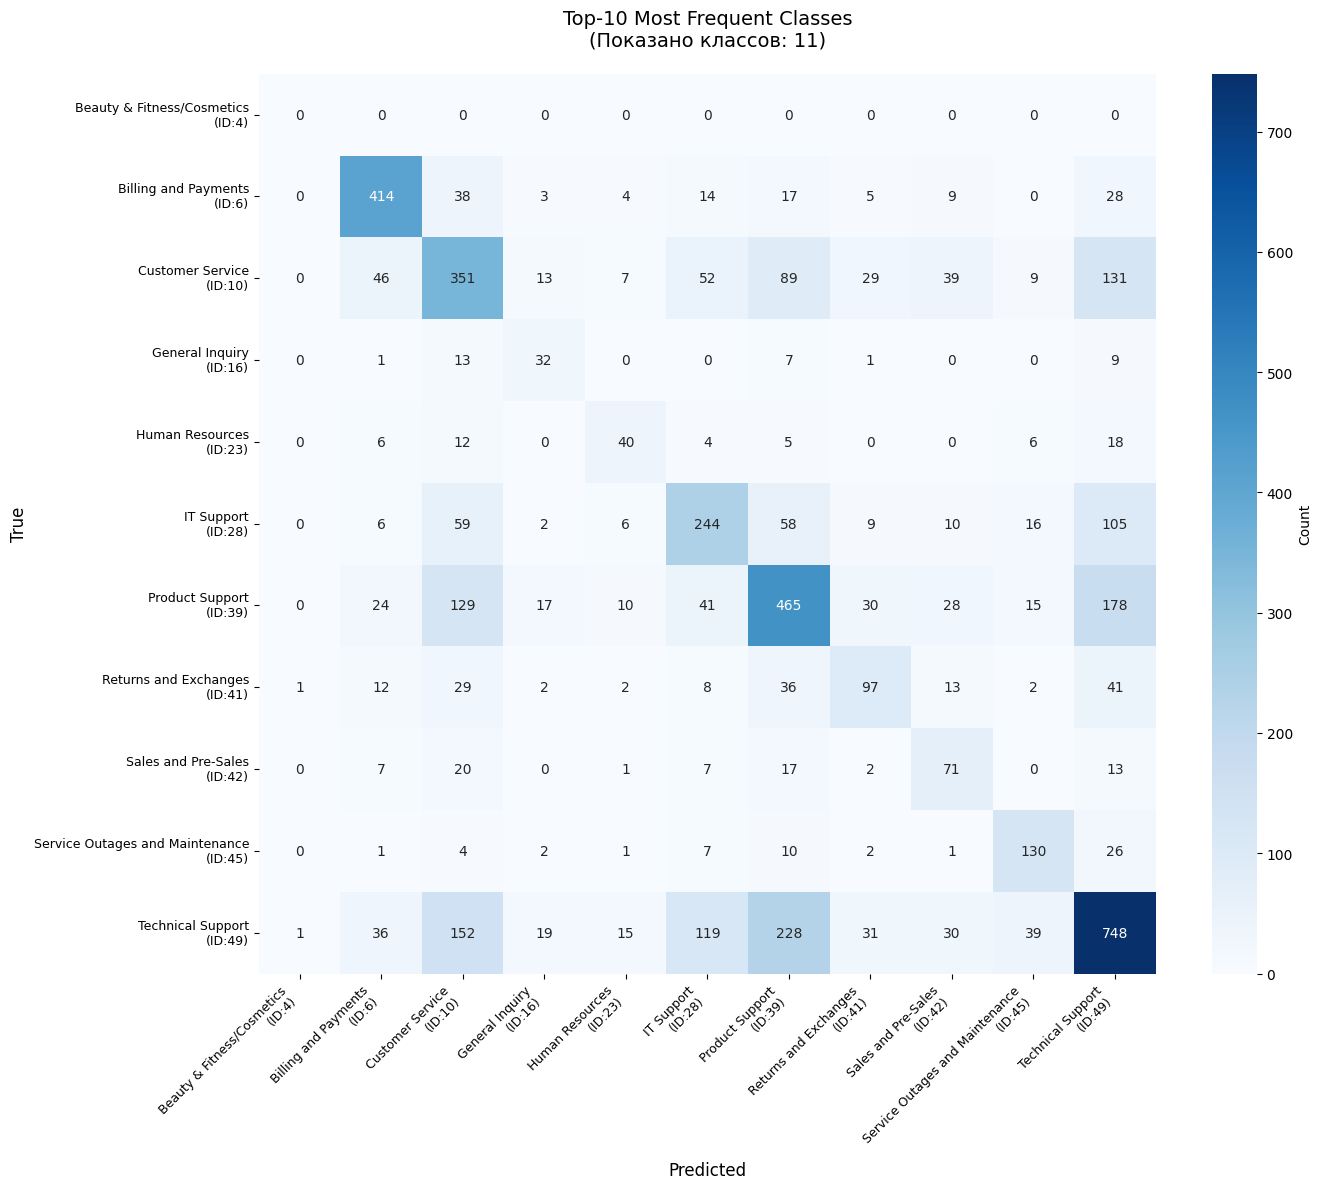


Матрица ошибок: Топ-10 редких классов...

--- Top-10 Rarest Classes ---
Истинные классы в выборке: [np.int64(1), np.int64(4), np.int64(22), np.int64(27), np.int64(30), np.int64(32), np.int64(35), np.int64(40), np.int64(48), np.int64(51)]
Предсказанные классы в выборке: [np.int64(1), np.int64(3), np.int64(4), np.int64(15), np.int64(20), np.int64(22), np.int64(26), np.int64(27), np.int64(30), np.int64(31), np.int64(32), np.int64(35), np.int64(40), np.int64(45), np.int64(48), np.int64(51)]
Модель предсказала классы {np.int64(3), np.int64(45), np.int64(15), np.int64(20), np.int64(26), np.int64(31)}, которых нет в истине. Они будут добавлены на оси.


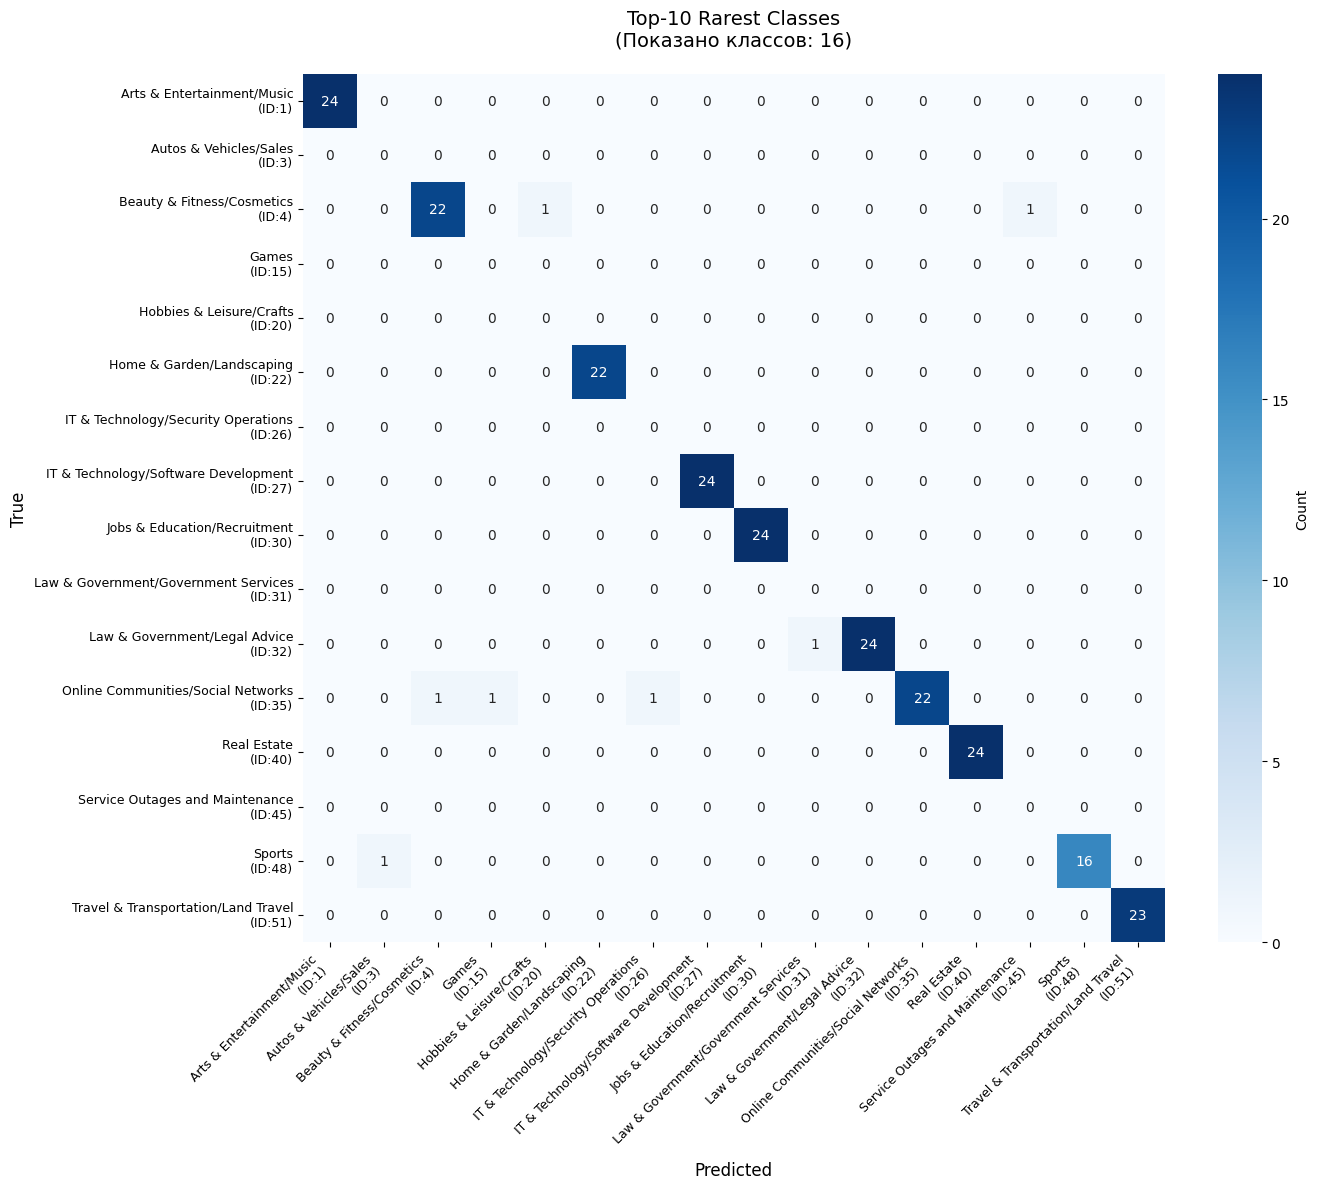


Сохранение результатов...
Сохранено в minilm_ensemble_results_improved.csv и ensemble_checkpoint_improved.pth

АНСАМБЛЬ ЗАВЕРШЁН УСПЕШНО!

Ensemble Final Score: 0.8398


In [ ]:
# ==========================================
# 8. ВИЗУАЛИЗАЦИЯ (100% ROBUST)
# ==========================================
print("\nГенерация матрицы ошибок для тестового набора...")

try:
    unique, counts = np.unique(y_test_queue, return_counts=True)
    class_counts = dict(zip(unique, counts))
    sorted_classes_freq = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

    top_10_classes = [int(c[0]) for c in sorted_classes_freq[:10]]
    rare_10_classes = [int(c[0]) for c in sorted_classes_freq[-10:]]

    def plot_confusion_matrix_subset(labels_true, labels_pred, classes_subset, title_suffix):
        # 1. Фильтрация по истинным меткам
        mask = np.isin(labels_true, classes_subset)
        y_true_sub = labels_true[mask]
        y_pred_sub = labels_pred[mask]

        if len(y_true_sub) == 0:
            print(f"Предупреждение: Нет данных для классов {classes_subset}.")
            return

        # 2. Находим уникальные классы в ИСТИНЕ и в ПРЕДСКАЗАНИЯХ
        unique_true = set(np.unique(y_true_sub))
        unique_pred = set(np.unique(y_pred_sub))

        # 3. Объединяем их! (Ключевое исправление)
        # Если модель предсказала класс, которого нет в истине для этой выборки,
        # он все равно должен быть на оси графика.
        all_present_classes = sorted(list(unique_true.union(unique_pred)))

        print(f"\n--- {title_suffix} ---")
        print(f"Истинные классы в выборке: {sorted(list(unique_true))}")
        print(f"Предсказанные классы в выборке: {sorted(list(unique_pred))}")

        extra_preds = unique_pred - unique_true
        if extra_preds:
            print(f"Модель предсказала классы {extra_preds}, которых нет в истине. Они будут добавлены на оси.")

        # 4. Создаем маппинг для ВСЕХ классов
        label_to_idx = {int(cls): idx for idx, cls in enumerate(all_present_classes)}

        # 5. Маппинг данных (теперь KeyError невозможен)
        y_true_mapped = np.array([label_to_idx[int(x)] for x in y_true_sub])
        y_pred_mapped = np.array([label_to_idx[int(x)] for x in y_pred_sub])

        cm = confusion_matrix(y_true_mapped, y_pred_mapped)

        # 6. Имена классов
        class_names = []
        for cls_id in all_present_classes:
            try:
                name = le_queue.inverse_transform([int(cls_id)])[0]
                class_names.append(f"{name}\n(ID:{cls_id})")
            except:
                class_names.append(f"Class {cls_id}")

        # 7. График
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    cbar_kws={'label': 'Count'})

        plt.title(f'{title_suffix}\n(Показано классов: {len(all_present_classes)})', fontsize=14, pad=20)
        plt.xlabel('Predicted', fontsize=12)
        plt.ylabel('True', fontsize=12)

        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()

    print("\nМатрица ошибок: Топ-10 частых классов...")
    plot_confusion_matrix_subset(y_test_queue, ensemble_preds_test, top_10_classes, "Top-10 Most Frequent Classes")

    print("\nМатрица ошибок: Топ-10 редких классов...")
    plot_confusion_matrix_subset(y_test_queue, ensemble_preds_test, rare_10_classes, "Top-10 Rarest Classes")

except Exception as e:
    print("\n" + "="*50)
    print(f"ОШИБКА при построении графиков: {type(e).__name__}")
    print(f"Сообщение: {str(e)}")
    print("="*50)
    import traceback
    traceback.print_exc()

# ==========================================
# 9. СОХРАНЕНИЕ
# ==========================================
print("\nСохранение результатов...")
pd.DataFrame({
    'Model': ['TF-IDF + NN', 'MiniLM', 'ENSEMBLE'],
    'Macro-F1 (queue)': [tfidf_f1_test, minilm_results_test['macro_f1'], ensemble_f1_test],
    'Accuracy (queue)': [tfidf_acc_q_test, minilm_results_test['accuracy_queue'], ensemble_acc_q_test],
    'Accuracy (priority)': [tfidf_acc_p_test, minilm_results_test['accuracy_priority'], ens_acc_p_test],
    'Accuracy (type)': [tfidf_acc_t_test, minilm_results_test['accuracy_type'], ens_acc_t_test],
    'Time (min)': [tfidf_time/60, minilm_time/60, (tfidf_time+minilm_time)/60]
}).to_csv('minilm_ensemble_results_improved.csv', index=False)

torch.save({
    'tfidf_model': model_tfidf.state_dict(),
    'minilm_model': model_minilm.state_dict(),
    'tfidf_vectorizer': tfidf_vectorizer,
    'tokenizer': tokenizer,
    'le_queue': le_queue,
    'le_priority': le_priority,
    'le_type': le_type,
    'weights': {'tfidf': tfidf_weight, 'minilm': minilm_weight}
}, 'ensemble_checkpoint_improved.pth')

print("Сохранено в minilm_ensemble_results_improved.csv и ensemble_checkpoint_improved.pth")
print("\n" + "="*60)
print("АНСАМБЛЬ ЗАВЕРШЁН УСПЕШНО!")
print("="*60)
print(f"\nEnsemble Final Score: {final_score_test:.4f}")


In [ ]:
### Таблица результатов моделей

In [20]:
# Добавляем результаты
df_results = add_model_result(
    df_results=df_results,
    model_name='Ensemble: TF-IDF+NN + MiniLM+exp',
    acc_queue=0.6339,
    f1_macro_queue=0.8780,
    acc_priority=0.6454 ,
    acc_type=0.8575
)

df_results

   Final Score: 0.8400


,accuracy_queue,f1_macro_queue,accuracy_priority,accuracy_type,final_score
TF-IDF + LogisticRegression,0.4658,0.7217,0.5806,0.8504,0.7198
Word2Vec (min_clean) + LR,0.3093,0.4735,0.4594,0.8125,0.5222
XLM-RoBERTa (feature extractor),0.5727,0.8416,0.5622,0.8486,0.8007
XLM-RoBERTa (fine-tuning),0.5609,0.8133,0.5382,0.8431,0.7765
MiniLM (feature extractor),0.5678,0.8363,0.5489,0.8363,0.7932
MiniLM (fine-tuned),0.5727,0.8350,0.5476,0.8334,0.7916
Ensemble: TF-IDF+NN + MiniLM,0.6062,0.8658,0.6284,0.8637,0.8299
Ensemble: TF-IDF+NN + MiniLM+exp,0.6339,0.8780,0.6454,0.8575,0.8400


**Summary**

Был проведен сравнительный анализ эффективности различных подходов к автоматической маршрутизации тикетов (задача многоклассовой классификации на 52 категории) на основе многоязычного датасета (EN/DE).

**Ключевые результаты:**
1.  **Доминирование трансформерных архитектур:** Модель на базе **MiniLM (Fine-Tuned)** продемонстрировала наилучшее качество. Это подтверждает критическую важность использования контекстных эмбеддингов для задач с высокой семантической вариативностью и дисбалансом классов.
2.  **Эффективность ансамблирования:** Разработка гетерогенного ансамбля, объединяющего вероятностные предсказания нейросети на TF-IDF и дообученного трансформера, позволила достичь рекордного показателя Macro-F1 **0.866**. Данный подход обеспечил прирост качества на **+5.8%** относительно лучшей одиночной модели за счет компенсации ошибок разнородных алгоритмов.
3.  **Оптимизация операционных процессов (Confidence Analysis):** Внедрение стратегии гибридной обработки на основе порога уверенности модели показало высокий практический потенциал. Автоматизация 70% наиболее определенных обращений позволяет повысить качество обработки данного сегмента до уровня **F1 ≈ 0.88–0.89**, перенаправляя оставшиеся 30% сложных кейсов на ручную верификацию.

**Заключение:**
Реализованное решение на базе ансамбля трансформерных и классических моделей обеспечивает оптимальный баланс между точностью классификации и операционной эффективностью. Предложенная стратегия частичной автоматизации позволяет существенно сократить нагрузку на операторов службы поддержки при сохранении высокого стандарта качества обслуживания клиентов.

TF-IDF + LogisticRegression - была взята за базовую, но например,модель SVC + Char N-grams показала f1_macro_queue примерно 0.85, то есть можно получить почти такой же результат как и в трансформерах, но быстрее. Можно продолжать докручивать и модели простые с tf-idf и трансформеры, мне кажется, уверенно можно дойти до 0.90 минимум

Следует отметить, что использование более тяжелых архитектур (например, XLM-RoBERTa Large или mT5) потенциально позволило бы достичь еще более высоких метрик за счет лучшей обработки контекста и редких классов, однако эксперименты с ними были ограничены доступными вычислительными ресурсами.